# Lecture 07: 训练神经网络 (Training Neural Networks)

本笔记从零开始讲解神经网络训练的核心技术，涵盖权重初始化、激活函数、批归一化、优化器、学习率调度、梯度检验与合理性检查。

**教学路径：** 直觉理解 -> 手动计算 -> 代码实现 -> 实验观察

**学习目标：**
- 理解不同权重初始化策略对深层网络训练的影响
- 掌握动量法与 Adam 优化器的数学原理和代码实现
- 实现梯度检验以验证反向传播的正确性
- 设计学习率调度策略并比较效果
- 执行训练前的合理性检查流程
- 理解 Dropout 和 AdamW 等正则化技术


## 目录

1. 环境设置与准备
2. 权重初始化：直觉与动机
3. 权重初始化：手动计算
4. 权重初始化：代码实现
5. 权重初始化：实验观察（3 张图）
6. 激活函数深度对比
7. 批归一化 (Batch Normalization)
8. 动量法 (Momentum SGD)
9. Adam 优化器
10. 学习率调度策略
11. 梯度检验 (Gradient Checking)
12. 训练合理性检查 (Sanity Checks)
13. Dropout 正则化
14. AdamW 与解耦权重衰减
15. 综合实验：完整训练流程
16. 关键要点总结
17. 作业练习
18. 参考文献与扩展阅读


In [3]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Figure output directory
fig_dir = r'd:/download/6aa68b099b47c2ba093ab510/cs231n-site/notebooks/part2-cnn-vision/lecture-07-training-nn'

print("Environment ready.")
print(f"NumPy version: {np.__version__}")
print(f"Random seed: 42")


Environment ready.
NumPy version: 2.2.6
Random seed: 42


## 1. 权重初始化：直觉与动机

### 为什么不能全部初始化为零？

如果所有权重初始化为相同的值（包括零），网络中的所有神经元将计算相同的输出，接收相同的梯度，进行相同的更新。这被称为**对称性问题**（symmetry problem）。

结果：深层网络退化为单层网络，所有神经元学到相同的特征。

### 好的初始化需要什么？

1. **打破对称性**：不同神经元应有不同的初始权重
2. **控制方差**：保持各层激活值的方差稳定，避免梯度爆炸或消失
3. **适配激活函数**：ReLU 需要不同于 Sigmoid 的初始化策略

### 核心直觉

想象信号通过多层网络传播：
- 如果权重太大 -> 激活值爆炸 -> 梯度爆炸 -> loss 变成 NaN
- 如果权重太小 -> 激活值消失 -> 梯度消失 -> 网络不学习
- **目标：保持信号方差在前向和后向传播中大致不变**


## 2. 权重初始化：手动计算

### 方差传播的数学直觉

考虑一个全连接层 $y = Wx + b$，其中 $x$ 有 $n$ 个输入。
假设各元素独立同分布，均值为 0：

$$Var(y_i) = \sum_{j=1}^{n} Var(W_{ij} \cdot x_j) = n \cdot Var(W_{ij}) \cdot Var(x_j)$$

为了让 $Var(y_i) = Var(x_j)$（方差保持不变），需要：

$$Var(W_{ij}) = \frac{1}{n}$$

这就是 **Xavier 初始化** 的核心思想！

### Xavier (Glorot) 初始化

适用于 tanh / sigmoid 激活函数：
- 均匀分布：$W \sim U(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}})$
- 正态分布：$W \sim N(0, \sqrt{\frac{2}{n_{in} + n_{out}}})$

**手动计算示例：** $n_{in} = 512, n_{out} = 256$
- 均匀分布范围：$\sqrt{6/768} \approx 0.0884$
- 正态分布标准差：$\sqrt{2/768} \approx 0.0510$

### He (Kaiming) 初始化

适用于 ReLU。ReLU 将一半输入置零，因此需要 2 倍方差补偿：
- 标准差：$\sqrt{\frac{2}{n_{in}}}$

**手动计算示例：** $n_{in} = 512$
- He 标准差：$\sqrt{2/512} \approx 0.0625$
- 对比 Xavier：$\sqrt{2/768} \approx 0.0510$（He 更大，补偿 ReLU 的零化效应）

### 前向传播方差变化预测

| 初始化方法 | 第1层方差 | 第5层方差 | 第10层方差 | 趋势 |
|---|---|---|---|---|
| 全零 | 0 | 0 | 0 | 完全失效 |
| N(0,1) | ~512 | 爆炸 | 爆炸 | 指数增长 |
| Xavier + tanh | ~1.0 | ~1.0 | ~1.0 | 稳定 |
| He + ReLU | ~1.0 | ~1.0 | ~1.0 | 稳定 |
| N(0,0.001) | 0.0005 | 极小 | 极小 | 消失 |


In [6]:
# ============================================================
# Weight Initialization Methods
# ============================================================

def init_zeros(n_in, n_out):
    """All zeros - demonstrates symmetry breaking problem."""
    return np.zeros((n_in, n_out))


def init_small_normal(n_in, n_out, std=0.01):
    """Small random normal - common but poor for deep nets."""
    return np.random.randn(n_in, n_out) * std


def init_xavier_uniform(n_in, n_out):
    """Xavier/Glorot uniform initialization - for tanh/sigmoid."""
    limit = np.sqrt(6.0 / (n_in + n_out))
    return np.random.uniform(-limit, limit, size=(n_in, n_out))


def init_xavier_normal(n_in, n_out):
    """Xavier/Glorot normal initialization - for tanh/sigmoid."""
    std = np.sqrt(2.0 / (n_in + n_out))
    return np.random.randn(n_in, n_out) * std


def init_he_normal(n_in, n_out):
    """He/Kaiming normal initialization - for ReLU."""
    std = np.sqrt(2.0 / n_in)
    return np.random.randn(n_in, n_out) * std


def init_he_uniform(n_in, n_out):
    """He/Kaiming uniform initialization - for ReLU."""
    limit = np.sqrt(6.0 / n_in)
    return np.random.uniform(-limit, limit, size=(n_in, n_out))


# Quick sanity test
np.random.seed(42)
W_test = init_he_normal(512, 256)
print("Weight initialization methods defined.")
print(f"He normal (512->256): mean={W_test.mean():.4f}, std={W_test.std():.4f}")
print(f"Expected std: {np.sqrt(2/512):.4f}")


Weight initialization methods defined.
He normal (512->256): mean=0.0001, std=0.0625
Expected std: 0.0625


In [7]:
# ============================================================
# Activation Functions
# ============================================================

def relu(x):
    """Rectified Linear Unit."""
    return np.maximum(0, x)


def relu_grad(x):
    """Gradient of ReLU."""
    return (x > 0).astype(float)


def tanh(x):
    """Hyperbolic tangent."""
    return np.tanh(x)


def tanh_grad(x):
    """Gradient of tanh."""
    return 1 - np.tanh(x) ** 2


def sigmoid(x):
    """Sigmoid function with numerical stability."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_grad(x):
    """Gradient of sigmoid."""
    s = sigmoid(x)
    return s * (1 - s)


def linear(x):
    """Identity / linear activation."""
    return x


print("Activation functions defined: relu, tanh, sigmoid, linear")
print("Each has a corresponding _grad function.")


Activation functions defined: relu, tanh, sigmoid, linear
Each has a corresponding _grad function.


## 3. 权重初始化：实验观察

让我们通过实验验证不同初始化方法在深层网络中的方差传播行为。

**实验设置：** 10 层全连接网络，每层 512 个神经元，输入 batch size = 1000


Figure 1 saved: init_variance.png

Key observation: Xavier+tanh and He+ReLU maintain stable variance near 1.0


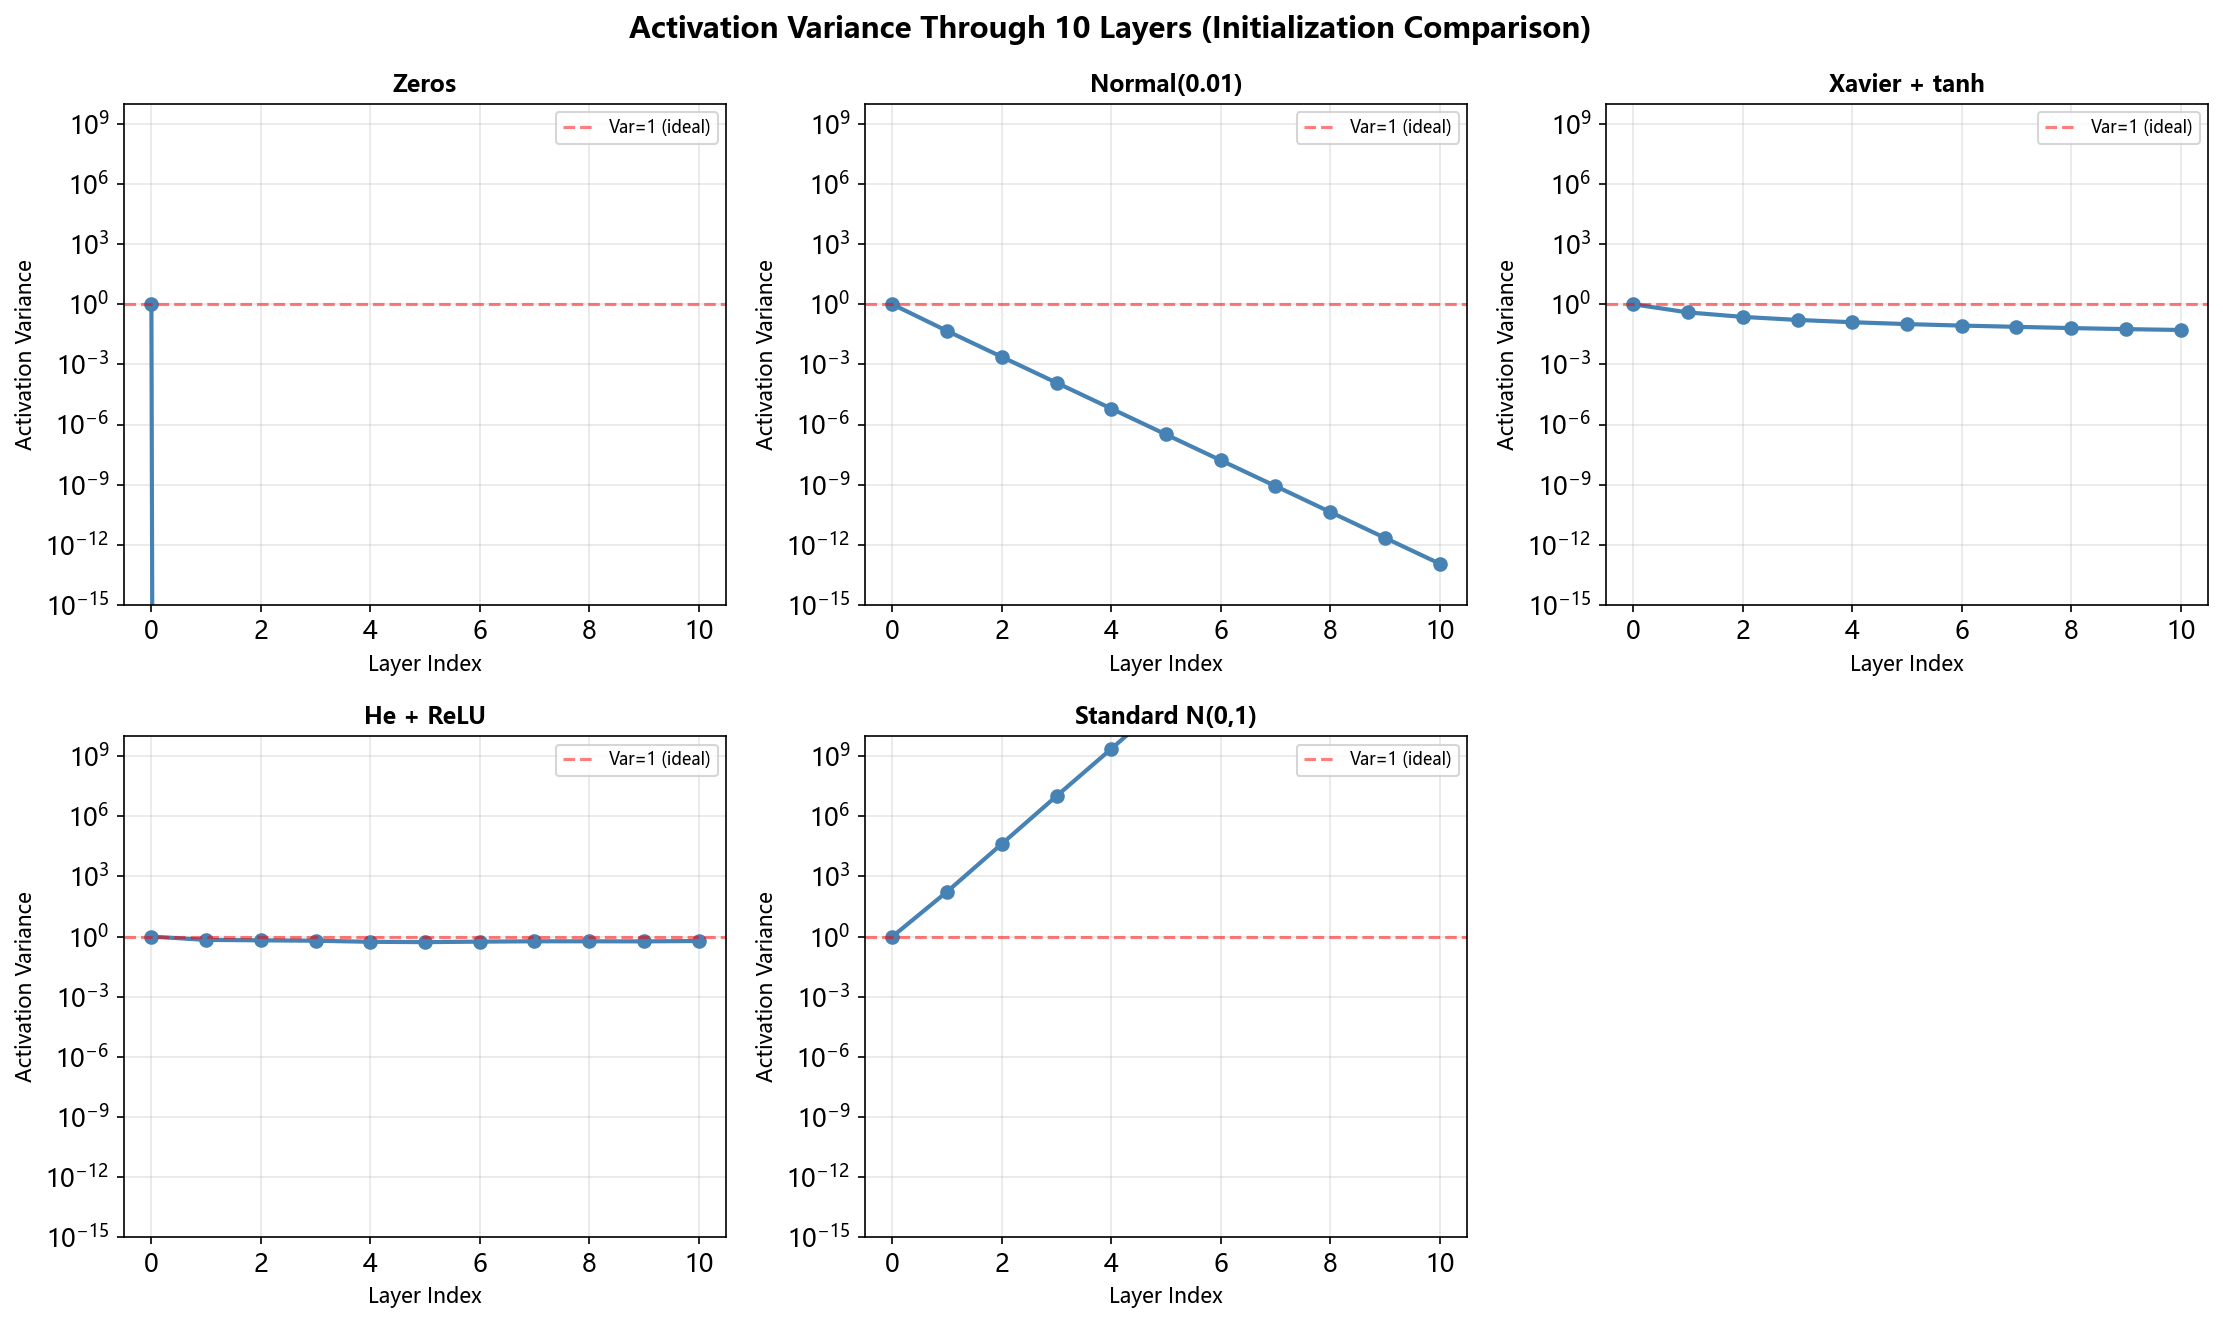

In [9]:
# ============================================================
# Experiment 1: Activation Variance Through Layers
# ============================================================

def forward_track_variance(Ws, x, activation):
    """Track activation mean and variance through each layer."""
    stats = []
    a = x.copy()
    stats.append((0, np.mean(a), np.var(a)))
    for i, W in enumerate(Ws):
        z = a @ W
        a = activation(z)
        stats.append((i + 1, np.mean(a), np.var(a)))
    return stats


# Build a 10-layer network, each layer 512 units
n_layers = 10
n_units = 512
x = np.random.randn(1000, n_units)  # batch of 1000 samples

# Test with different initializations
configs = {
    'Zeros': (init_zeros, tanh),
    'Normal(0.01)': (init_small_normal, tanh),
    'Xavier + tanh': (init_xavier_normal, tanh),
    'He + ReLU': (init_he_normal, relu),
    'Standard N(0,1)': (lambda a, b: np.random.randn(a, b), relu),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, (init_fn, act_fn)) in enumerate(configs.items()):
    np.random.seed(42)
    Ws = [init_fn(n_units, n_units) for _ in range(n_layers)]
    stats = forward_track_variance(Ws, x, act_fn)
    layers = [s[0] for s in stats]
    variances = [s[2] for s in stats]
    ax = axes[idx]
    ax.plot(layers, variances, 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.set_xlabel('Layer Index', fontsize=10)
    ax.set_ylabel('Activation Variance', fontsize=10)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(1e-15, 1e10)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Var=1 (ideal)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the unused subplot
axes[-1].axis('off')

plt.suptitle('Activation Variance Through 10 Layers (Initialization Comparison)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(fig_dir + '/init_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved: init_variance.png")
print("\nKey observation: Xavier+tanh and He+ReLU maintain stable variance near 1.0")


Figure 2 saved: init_distributions.png


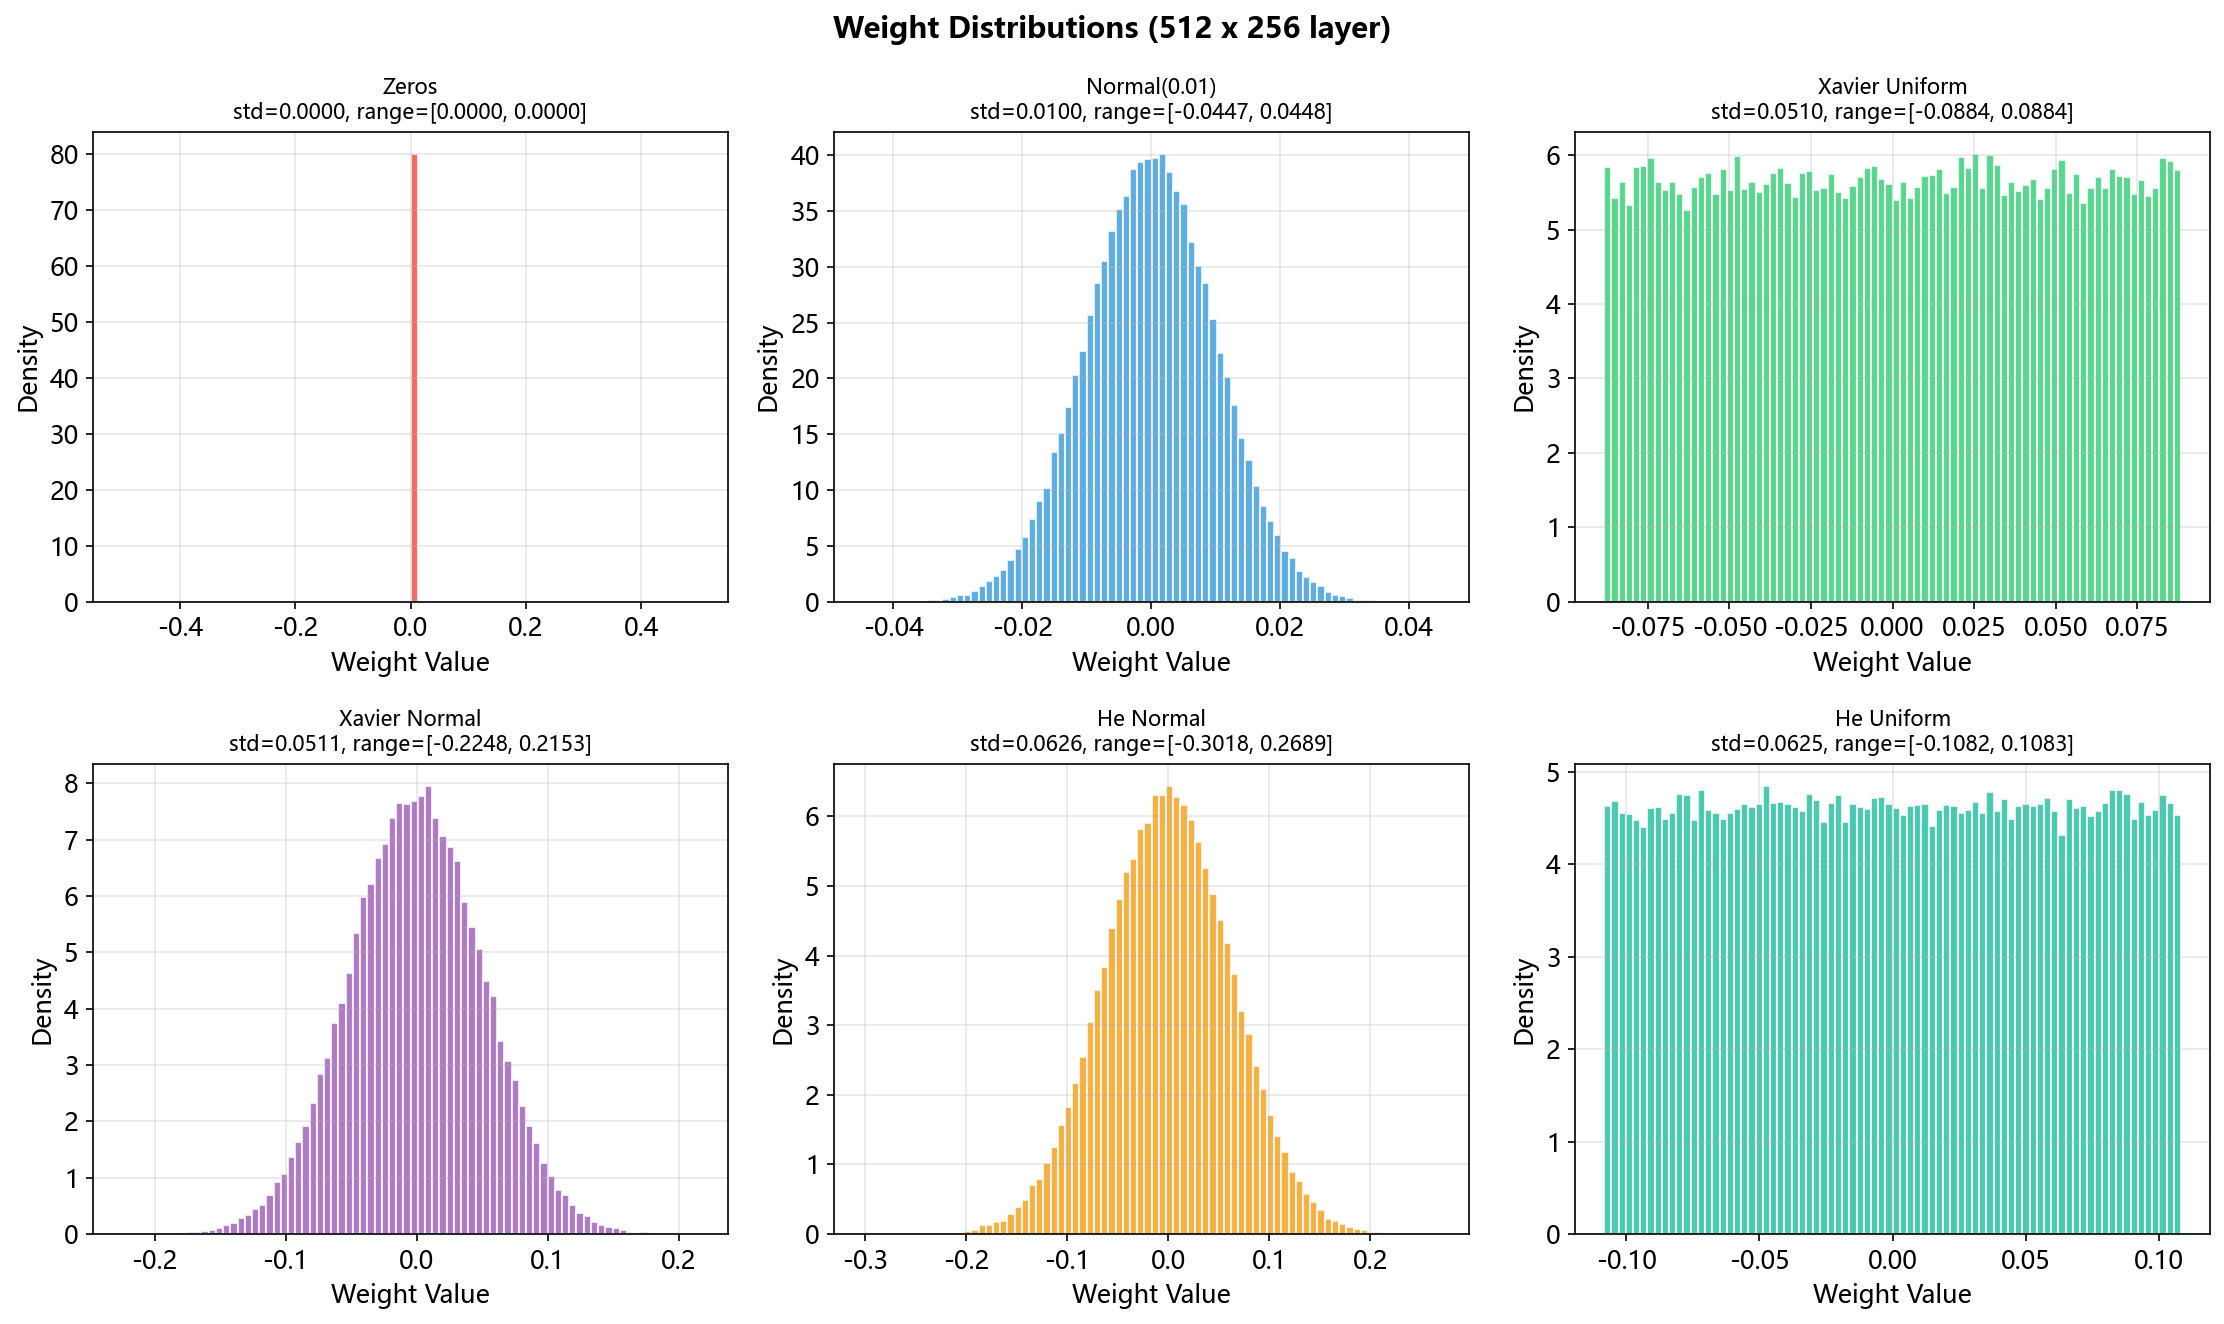

In [10]:
# ============================================================
# Experiment 2: Weight Distribution Histograms
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
n_in, n_out = 512, 256

np.random.seed(42)
init_methods = {
    'Zeros': init_zeros(n_in, n_out),
    'Normal(0.01)': init_small_normal(n_in, n_out),
    'Xavier Uniform': init_xavier_uniform(n_in, n_out),
    'Xavier Normal': init_xavier_normal(n_in, n_out),
    'He Normal': init_he_normal(n_in, n_out),
    'He Uniform': init_he_uniform(n_in, n_out),
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for idx, (name, W) in enumerate(init_methods.items()):
    ax = axes[idx]
    ax.hist(W.flatten(), bins=80, density=True, color=colors[idx],
            edgecolor='white', alpha=0.8)
    ax.set_title(f'{name}\nstd={np.std(W):.4f}, range=[{W.min():.4f}, {W.max():.4f}]',
                 fontsize=10)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

plt.suptitle('Weight Distributions (512 x 256 layer)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(fig_dir + '/init_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: init_distributions.png")


Figure 3 saved: gradient_flow.png

Key observation: Proper initialization keeps gradient norms stable.
N(0,1) causes gradient explosion; small normal causes vanishing.


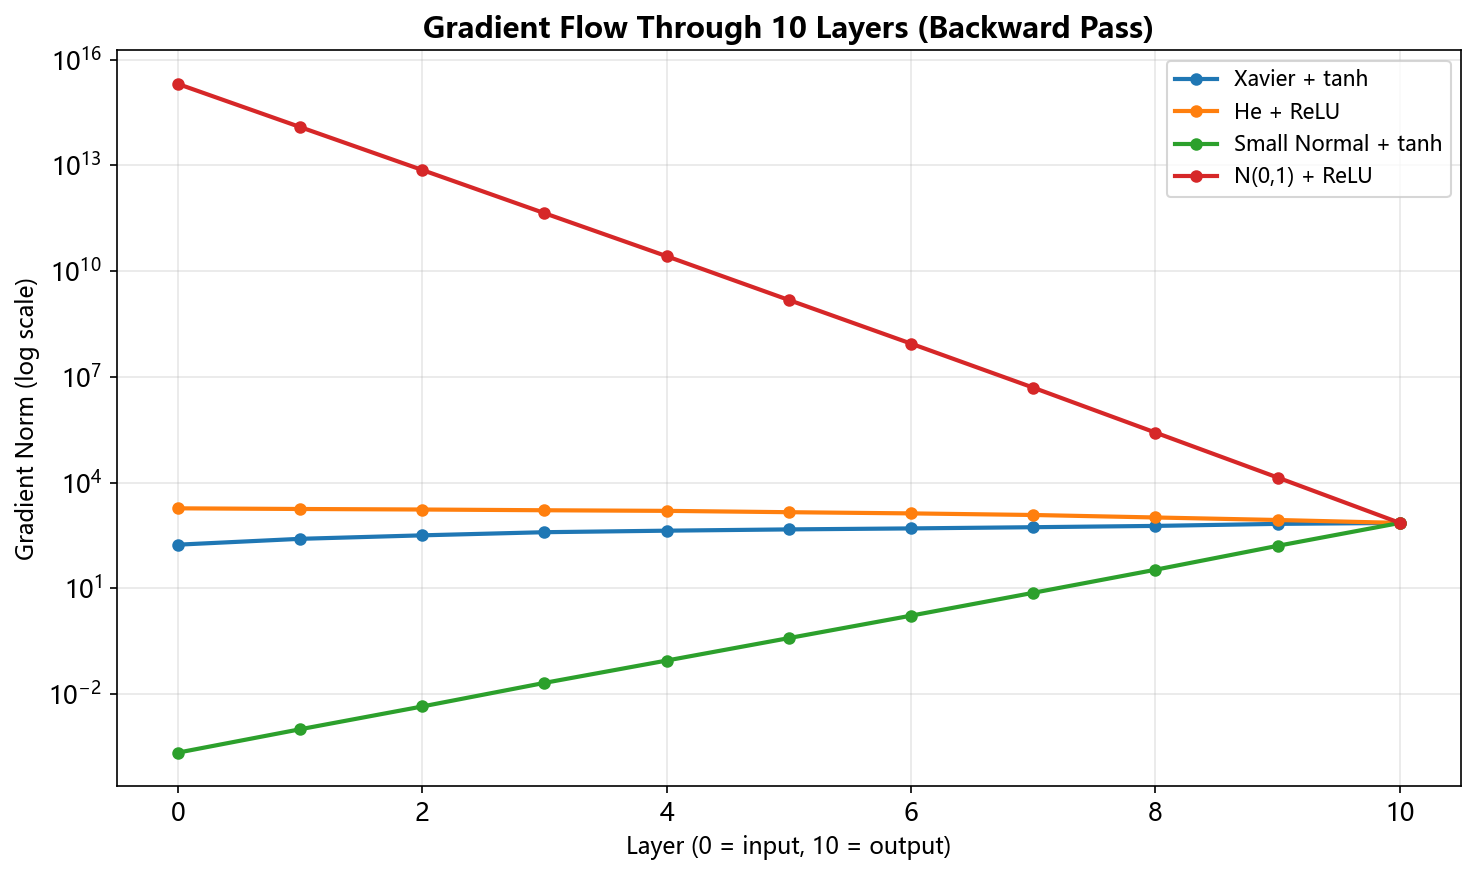

In [11]:
# ============================================================
# Experiment 3: Gradient Flow Through Backward Pass
# ============================================================

def backward_track_gradient(Ws, x, activation, act_grad_fn):
    """Track gradient magnitude through backward pass."""
    # Forward pass
    activations = [x.copy()]
    pre_acts = []
    a = x.copy()
    for W in Ws:
        z = a @ W
        pre_acts.append(z)
        a = activation(z)
        activations.append(a)
    # Backward pass
    grad = np.ones_like(activations[-1])
    grad_norms = [np.linalg.norm(grad)]
    for i in range(len(Ws) - 1, -1, -1):
        grad = grad * act_grad_fn(pre_acts[i])
        grad = grad @ Ws[i].T
        grad_norms.append(np.linalg.norm(grad))
    grad_norms.reverse()
    return grad_norms


fig, ax = plt.subplots(figsize=(10, 6))

test_cases = [
    ('Xavier + tanh', init_xavier_normal, tanh, tanh_grad),
    ('He + ReLU', init_he_normal, relu, relu_grad),
    ('Small Normal + tanh', init_small_normal, tanh, tanh_grad),
    ('N(0,1) + ReLU', lambda a, b: np.random.randn(a, b), relu, relu_grad),
]

for name, init_fn, act_fn, grad_fn in test_cases:
    np.random.seed(42)
    Ws = [init_fn(n_units, n_units) for _ in range(n_layers)]
    grad_norms = backward_track_gradient(Ws, x, act_fn, grad_fn)
    layers = list(range(len(grad_norms)))
    ax.plot(layers, grad_norms, 'o-', linewidth=2, markersize=5, label=name)

ax.set_xlabel('Layer (0 = input, 10 = output)', fontsize=11)
ax.set_ylabel('Gradient Norm (log scale)', fontsize=11)
ax.set_title('Gradient Flow Through 10 Layers (Backward Pass)',
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir + '/gradient_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved: gradient_flow.png")
print("\nKey observation: Proper initialization keeps gradient norms stable.")
print("N(0,1) causes gradient explosion; small normal causes vanishing.")


## 4. 激活函数深度对比

### 直觉

激活函数为神经网络引入非线性。没有非线性，多层网络等价于单层线性变换。

### 各激活函数的特性

| 激活函数 | 公式 | 优点 | 缺点 |
|---|---|---|---|
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | 输出在 (0,1)，可解释为概率 | 梯度消失（两端饱和），输出非零均值 |
| Tanh | $\tanh(x)$ | 输出在 (-1,1)，零均值 | 仍有梯度消失问题 |
| ReLU | $max(0, x)$ | 计算快，无正端饱和，稀疏激活 | 负端梯度为 0（dead ReLU），输出非零均值 |

### 为什么 ReLU 是当前主流选择？

1. **计算高效**：只需一次比较操作
2. **缓解梯度消失**：正半轴梯度恒为 1
3. **稀疏激活**：约一半神经元处于激活状态，更接近生物神经元
4. **实际效果好**：在大量实验中被验证有效


Figure 4 saved: activations.png

Key insight: Sigmoid and tanh saturate at the tails -> gradient vanishing.
ReLU has constant gradient 1 for x > 0 -> no vanishing in positive region.


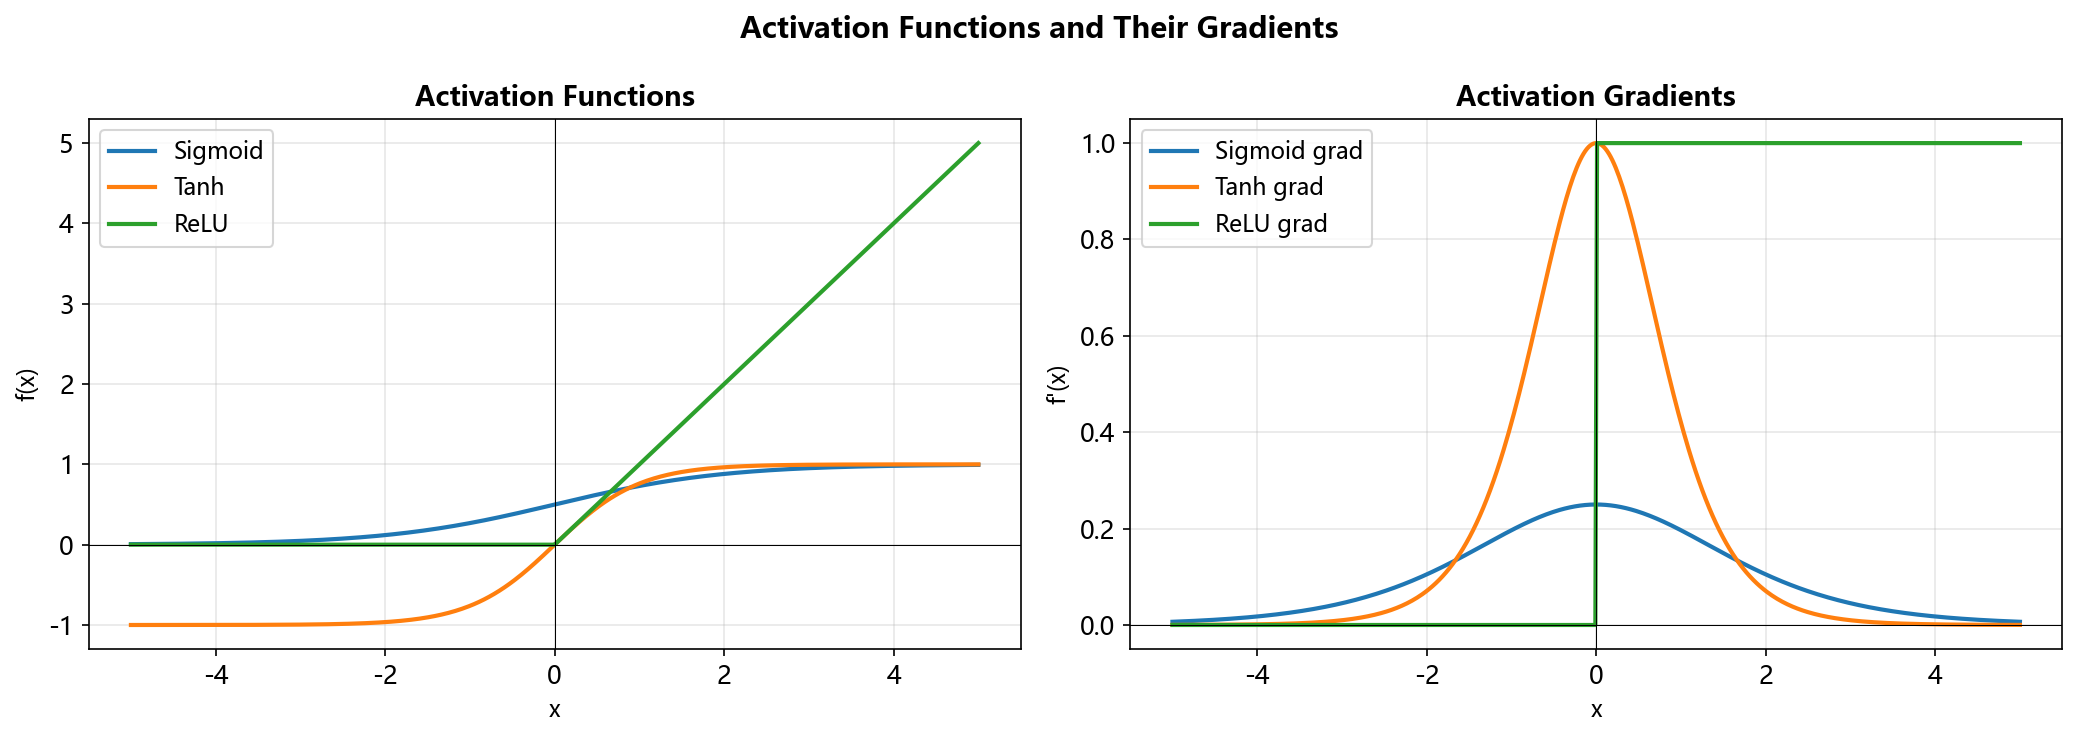

In [13]:
# ============================================================
# Experiment 4: Activation Functions and Their Gradients
# ============================================================

x_act = np.linspace(-5, 5, 500)

activations_plot = {
    'Sigmoid': (sigmoid(x_act), sigmoid_grad(x_act)),
    'Tanh': (tanh(x_act), tanh_grad(x_act)),
    'ReLU': (relu(x_act), relu_grad(x_act)),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: activation functions
for name, (f_val, _) in activations_plot.items():
    axes[0].plot(x_act, f_val, linewidth=2, label=name)
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
axes[0].set_title('Activation Functions', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Right: gradients
for name, (_, g_val) in activations_plot.items():
    axes[1].plot(x_act, g_val, linewidth=2, label=name + " grad")
axes[1].set_xlabel('x', fontsize=11)
axes[1].set_ylabel("f'(x)", fontsize=11)
axes[1].set_title('Activation Gradients', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.suptitle('Activation Functions and Their Gradients', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(fig_dir + '/activations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved: activations.png")
print("\nKey insight: Sigmoid and tanh saturate at the tails -> gradient vanishing.")
print("ReLU has constant gradient 1 for x > 0 -> no vanishing in positive region.")


### 「死亡 ReLU」问题 (Dying ReLU)

### 直觉

ReLU 的一个潜在问题是：当神经元的输入始终小于 0 时，该神经元的梯度恒为 0，权重永远不会更新，神经元「死亡」。

**原因：**
- 偏置初始化为负值太大 -> 很多神经元一开始就死了
- 学习率太大 -> 权重更新过度，导致某些神经元永远关闭

**解决方案：**
1. 使用 He 初始化（更仔细的初始化策略）
2. 使用较小的学习率
3. 使用 Leaky ReLU / PReLU（给负值区域一个小斜率）
4. 使用 BatchNorm（保持激活分布稳定）

**Leaky ReLU:** $f(x) = \max(\alpha x, x)$，通常 $\alpha = 0.01$


Figure 5 saved: dead_relu.png

Key insight: Poor initialization + ReLU causes many neurons to die.
Leaky ReLU and He initialization help mitigate this problem.


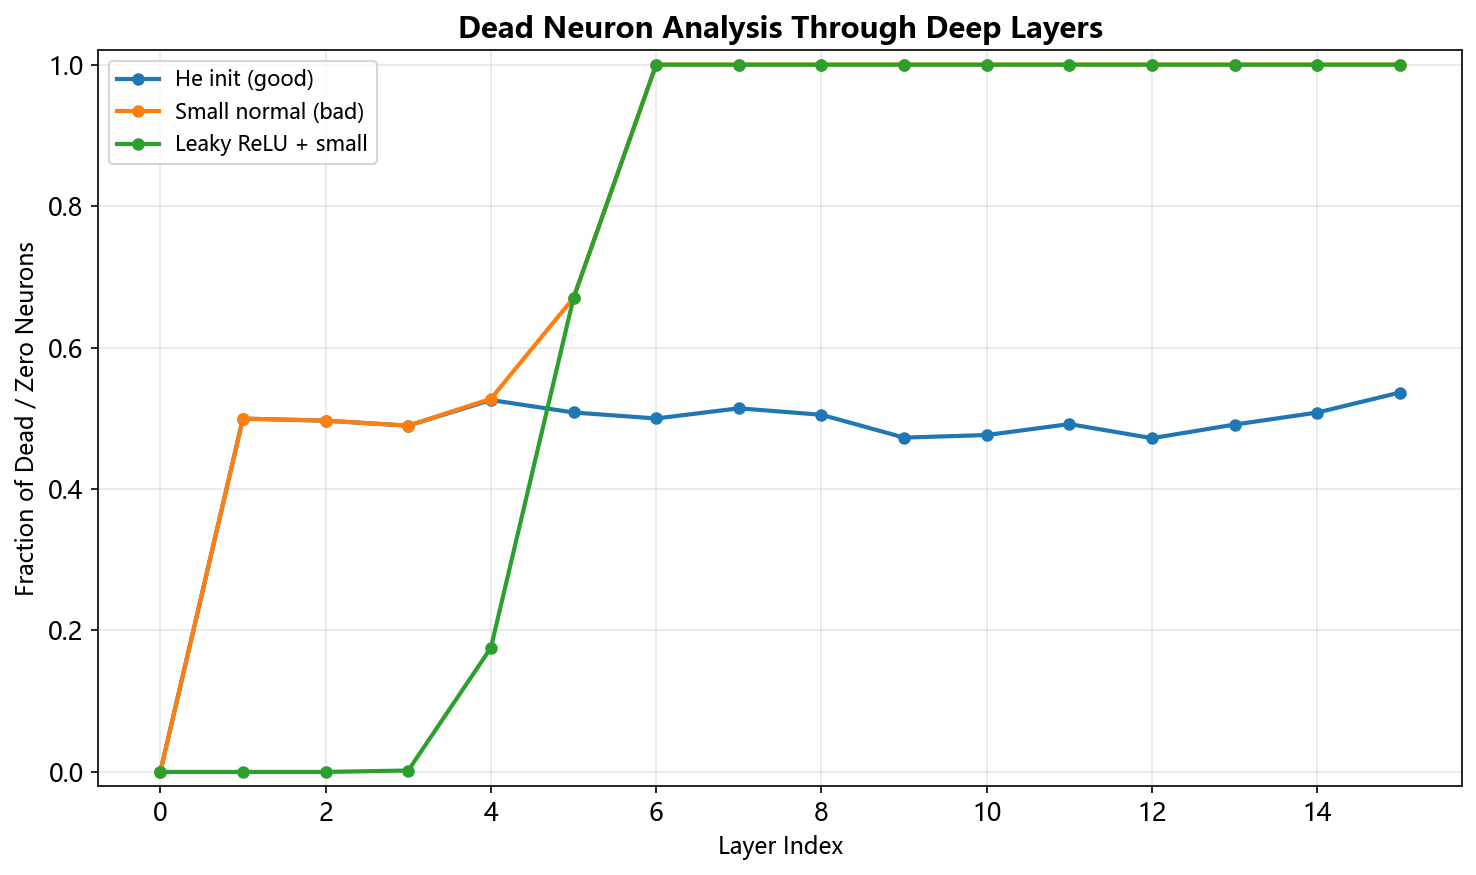

In [15]:
# ============================================================
# Experiment: Dead ReLU Analysis
# ============================================================

def leaky_relu(x, alpha=0.01):
    """Leaky ReLU activation."""
    return np.where(x > 0, x, alpha * x)


# Simulate fraction of dead neurons through layers
np.random.seed(42)
n_layers_dead = 15
n_units_dead = 256
x_dead = np.random.randn(500, n_units_dead)

init_configs = {
    'He init (good)': (init_he_normal, relu),
    'Small normal (bad)': (lambda a, b: init_small_normal(a, b, std=0.001), relu),
    'Leaky ReLU + small': (lambda a, b: init_small_normal(a, b, std=0.001), leaky_relu),
}

fig, ax = plt.subplots(figsize=(10, 6))

for name, (init_fn, act_fn) in init_configs.items():
    np.random.seed(42)
    Ws = [init_fn(n_units_dead, n_units_dead) for _ in range(n_layers_dead)]
    a = x_dead.copy()
    dead_frac = []
    # Layer 0 is input
    dead_frac.append(0.0)
    for W in Ws:
        z = a @ W
        a = act_fn(z)
        # Fraction of neurons that are always 0 across the batch
        dead = (np.abs(a) < 1e-10).mean()
        dead_frac.append(dead)
    ax.plot(range(len(dead_frac)), dead_frac, 'o-', linewidth=2, markersize=5, label=name)

ax.set_xlabel('Layer Index', fontsize=11)
ax.set_ylabel('Fraction of Dead / Zero Neurons', fontsize=11)
ax.set_title('Dead Neuron Analysis Through Deep Layers',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
fig.savefig(fig_dir + '/dead_relu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved: dead_relu.png")
print("\nKey insight: Poor initialization + ReLU causes many neurons to die.")
print("Leaky ReLU and He initialization help mitigate this problem.")


## 5. 批归一化 (Batch Normalization)

### 直觉

在训练过程中，每层输入的分布不断变化（因为前面层的权重在更新），这被称为**内部协变量偏移**（Internal Covariate Shift）。

批归一化通过在每个层对激活值进行标准化，使每层输入分布稳定，从而：

1. 允许使用更大的学习率，加速训练
2. 减少对权重初始化的敏感度
3. 具有轻微的正则化效果（batch 噪声）
4. 使深层网络更容易训练

### 手动计算

对于 mini-batch $B = \{x_1, ..., x_m\}$：

**步骤 1：计算批次均值**
$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i$$

**步骤 2：计算批次方差**
$$\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m} (x_i - \mu_B)^2$$

**步骤 3：标准化**
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

**步骤 4：缩放和平移**
$$y_i = \gamma \cdot \hat{x}_i + \beta$$

其中 $\gamma$ 和 $\beta$ 是可学习参数。如果 $\gamma = \sqrt{\sigma_B^2 + \epsilon}$ 且 $\beta = \mu_B$，则恒等变换。

**数值示例：**
- 输入: $x = [1.0, 2.0, 3.0, 4.0]$
- 均值: $\mu = 2.5$
- 方差: $\sigma^2 = 1.25$
- 标准化: $\hat{x} = [-1.34, -0.45, 0.45, 1.34]$
- 若 $\gamma=2, \beta=1$: $y = [-1.68, 0.10, 1.90, 3.68]$

**参考论文：** [[Ioffe and Szegedy, 2015]](https://arxiv.org/abs/1502.03167)


In [17]:
# ============================================================
# Batch Normalization Implementation
# ============================================================

class BatchNorm:
    """Batch Normalization for fully connected layers."""

    def __init__(self, dim, momentum=0.9, eps=1e-5):
        self.gamma = np.ones(dim)       # scale parameter
        self.beta = np.zeros(dim)       # shift parameter
        self.momentum = momentum        # for running mean/var
        self.eps = eps
        self.running_mean = np.zeros(dim)
        self.running_var = np.ones(dim)

    def forward(self, x, training=True):
        """Forward pass."""
        if training:
            batch_mean = x.mean(axis=0)
            batch_var = x.var(axis=0)
            # Update running statistics
            self.running_mean = (self.momentum * self.running_mean
                                 + (1 - self.momentum) * batch_mean)
            self.running_var = (self.momentum * self.running_var
                                + (1 - self.momentum) * batch_var)
            x_norm = (x - batch_mean) / np.sqrt(batch_var + self.eps)
        else:
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
        return self.gamma * x_norm + self.beta

    def backward(self, x, dout):
        """Backward pass, returns (dx, dgamma, dbeta)."""
        N = x.shape[0]
        batch_mean = x.mean(axis=0)
        batch_var = x.var(axis=0)
        x_norm = (x - batch_mean) / np.sqrt(batch_var + self.eps)

        # Gradients w.r.t. gamma and beta
        dgamma = (dout * x_norm).sum(axis=0)
        dbeta = dout.sum(axis=0)

        # Gradient w.r.t. input x
        dx_norm = dout * self.gamma
        dvar = (dx_norm * (x - batch_mean) *
                -0.5 * (batch_var + self.eps)**(-1.5)).sum(axis=0)
        dmean = (dx_norm * (-1.0 / np.sqrt(batch_var + self.eps))).sum(axis=0)
        dmean += dvar * (-2.0 * (x - batch_mean)).mean(axis=0)
        dx = (dx_norm / np.sqrt(batch_var + self.eps)
              + dvar * 2.0 * (x - batch_mean) / N
              + dmean / N)
        return dx, dgamma, dbeta


# Test BatchNorm
np.random.seed(42)
bn = BatchNorm(64)
x_test = np.random.randn(32, 64) * 3 + 5  # mean=5, std=3
out = bn.forward(x_test, training=True)

print("BatchNorm test results:")
print(f"Input  - mean: {x_test.mean():.4f}, std: {x_test.std():.4f}")
print(f"Output - mean: {out.mean():.4f}, std: {out.std():.4f}")
print("Output mean should be ~0 (beta=0), std ~1 (gamma=1)")


BatchNorm test results:
Input  - mean: 5.1214, std: 2.9699
Output - mean: 0.0000, std: 1.0000
Output mean should be ~0 (beta=0), std ~1 (gamma=1)


Training without BN...
Training with BN...
Figure 5 saved: bn_effect.png

Final loss - No BN: 0.0317
Final loss - With BN: 0.0520


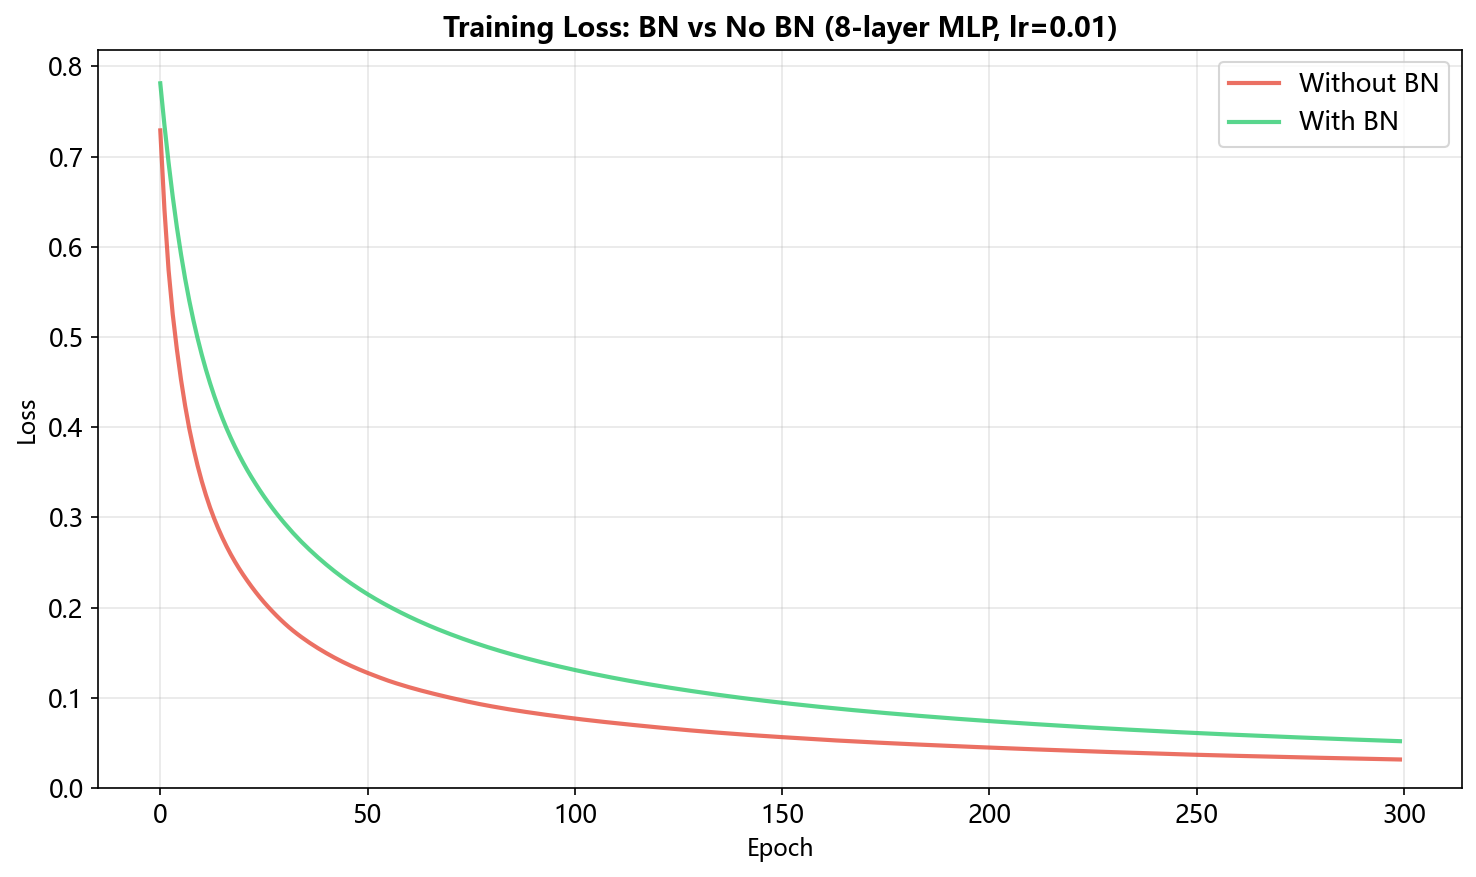

In [18]:
# ============================================================
# Experiment 5: BN Effect on Deep Network Training
# ============================================================

def train_simple_net(use_bn=False, n_epochs=300, lr=0.01, depth=8, width=128):
    """Train a deep MLP with/without BN on synthetic XOR-like data."""
    np.random.seed(42)
    N = 500
    X = np.random.randn(N, 2)
    y = (X[:, 0] * X[:, 1] > 0).astype(int)

    # Initialize weights
    Ws = [init_he_normal(2, width)]
    Ws += [init_he_normal(width, width) for _ in range(depth - 2)]
    Ws += [init_he_normal(width, 2)]

    bns = [BatchNorm(width) for _ in range(depth - 1)] if use_bn else None

    losses = []
    for epoch in range(n_epochs):
        # Forward pass
        a = X
        cache = [a]
        pre_acts = []
        for i in range(depth - 1):
            z = a @ Ws[i]
            if use_bn:
                z = bns[i].forward(z, training=True)
            pre_acts.append(z)
            a = relu(z)
            cache.append(a)
        out = a @ Ws[-1]

        # Softmax loss
        shifted = out - out.max(axis=1, keepdims=True)
        exp_out = np.exp(shifted)
        probs = exp_out / exp_out.sum(axis=1, keepdims=True)
        loss = -np.log(probs[np.arange(N), y] + 1e-12).mean()
        losses.append(loss)

        # Backward pass
        dout = probs.copy()
        dout[np.arange(N), y] -= 1
        dout /= N

        dW_last = cache[-1].T @ dout
        da = dout @ Ws[-1].T
        Ws[-1] -= lr * dW_last

        for i in range(depth - 2, -1, -1):
            dz = da * (cache[i + 1] > 0).astype(float)
            if use_bn:
                dz, dgamma, dbeta = bns[i].backward(pre_acts[i], dz)
                bns[i].gamma -= lr * dgamma
                bns[i].beta -= lr * dbeta
            dW = cache[i].T @ dz
            Ws[i] -= lr * dW
            da = dz @ Ws[i].T

    return losses


# Run experiments
print("Training without BN...")
losses_no_bn = train_simple_net(use_bn=False, n_epochs=300, lr=0.01)
print("Training with BN...")
losses_bn = train_simple_net(use_bn=True, n_epochs=300, lr=0.01)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(losses_no_bn, label='Without BN', alpha=0.8, linewidth=2, color='#e74c3c')
ax.plot(losses_bn, label='With BN', alpha=0.8, linewidth=2, color='#2ecc71')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training Loss: BN vs No BN (8-layer MLP, lr=0.01)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(fig_dir + '/bn_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved: bn_effect.png")
print(f"\nFinal loss - No BN: {losses_no_bn[-1]:.4f}")
print(f"Final loss - With BN: {losses_bn[-1]:.4f}")


### BatchNorm vs LayerNorm 对比

BatchNorm 和 LayerNorm 都是归一化技术，但归一化的维度不同：

| 特性 | BatchNorm | LayerNorm |
|---|---|---|
| 归一化维度 | 批次维度 (沿 N 轴) | 特征维度 (沿 D 轴) |
| 公式 | 每个特征在 batch 上归一化 | 每个样本在特征上归一化 |
| 依赖 batch size | 是，batch 小效果差 | 否，batch=1 也能用 |
| RNN/Transformer | 不合适（序列长度变化） | 合适，已成为标准配置 |
| 推理时 | 需要维护 running mean/var | 不需要，和训练一致 |
| 正则化效果 | 有（batch 噪声） | 无 |

**为什么 Transformer 用 LayerNorm 而不用 BatchNorm？**

1. 序列长度可变，batch 内样本长度不一致时 BN 统计量有偏
2. 小 batch 时 BN 效果显著下降，而大模型训练常受显存限制
3. LayerNorm 对每个样本独立计算，更适合并行和分布式训练
4. 推理时无需维护 running statistics，部署更简单


## 7. 动量法 (Momentum SGD)

### 直觉

想象一个球在损失曲面上滚动。标准 SGD 每步只看当前梯度方向，而动量法积累了历史梯度方向，像物理动量一样：

- 在平坦区域加速（梯度方向一致时）
- 在谷底减少振荡（梯度方向交替时）
- 能越过局部最优和鞍点

### 手动计算

**标准动量法更新规则：**
$$v_t = \mu \cdot v_{t-1} - \eta \cdot \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t + v_t$$

其中 $\mu$ 是动量系数（通常 0.9），$\eta$ 是学习率。

**数值示例：** 在 $f(\theta) = \theta^2$ 上
- 初始 $\theta_0 = 1.0, v_0 = 0, \mu = 0.9, \eta = 0.1$
- 梯度 $g_0 = 2\theta_0 = 2.0$
- $v_1 = 0.9 \times 0 - 0.1 \times 2.0 = -0.2$
- $\theta_1 = 1.0 + (-0.2) = 0.8$
- 下一步梯度 $g_1 = 2 \times 0.8 = 1.6$
- $v_2 = 0.9 \times (-0.2) - 0.1 \times 1.6 = -0.18 - 0.16 = -0.34$
- $\theta_2 = 0.8 + (-0.34) = 0.46$

注意 $|v_2| > |v_1|$，动量在加速！

### Nesterov 动量

$$v_t = \mu \cdot v_{t-1} - \eta \cdot \nabla L(\theta_t + \mu \cdot v_{t-1})$$

Nesterov 在计算梯度前「提前看一步」，在凸函数上有更好的理论收敛率。

**参考论文：** [[Sutskever et al., 2013]](http://proceedings.mlr.press/v28/sutskever13.html)


## 7. Adam 优化器：自适应学习率

### 直觉

Adam (Adaptive Moment Estimation) 结合了：
- **动量思想**（一阶矩估计）：积累历史梯度方向
- **RMSProp 思想**（二阶矩估计）：为每个参数自适应调整学习率

梯度变化大的参数获得更小的有效学习率，反之亦然。这使得 Adam 对学习率的选择不那么敏感。

### 手动计算

**更新规则：**
$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t \quad \text{（一阶矩）}$$
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2 \quad \text{（二阶矩）}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \quad \text{（偏差修正）}$$
$$\hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{（偏差修正）}$$
$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**数值示例：** 在 $f(\theta) = \theta^2, \theta_0 = 1.0$ 上
- $\beta_1 = 0.9, \beta_2 = 0.999, \eta = 0.1$
- $g_1 = 2.0$
- $m_1 = 0.9 \times 0 + 0.1 \times 2.0 = 0.2$
- $v_1 = 0.999 \times 0 + 0.001 \times 4.0 = 0.004$
- 偏差修正: $\hat{m}_1 = 0.2 / (1 - 0.9) = 2.0, \hat{v}_1 = 0.004 / (1 - 0.999) = 4.0$
- 更新: $\theta_1 = 1.0 - 0.1 \times 2.0 / (\sqrt{4.0} + 10^{-8}) = 0.9$

偏差修正确保初始步长不会过小（因为 m 和 v 初始化为 0）！

**参考论文：** [[Kingma and Ba, 2015]](https://arxiv.org/abs/1412.6980)


In [22]:
# ============================================================
# Optimizer Implementations
# ============================================================

class SGD:
    """Vanilla Stochastic Gradient Descent."""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads[k]
        return params


class SGDMomentum:
    """SGD with momentum."""

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = {}  # velocity

    def update(self, params, grads):
        for k in params:
            if k not in self.v:
                self.v[k] = np.zeros_like(params[k])
            self.v[k] = self.momentum * self.v[k] - self.lr * grads[k]
            params[k] += self.v[k]
        return params


class Adam:
    """Adam optimizer with bias correction."""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}  # first moment
        self.v = {}  # second moment
        self.t = 0   # time step

    def update(self, params, grads):
        self.t += 1
        for k in params:
            if k not in self.m:
                self.m[k] = np.zeros_like(params[k])
                self.v[k] = np.zeros_like(params[k])
            # Update biased moment estimates
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            # Bias correction
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            # Update
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


print("Optimizers defined: SGD, SGDMomentum, Adam")


Optimizers defined: SGD, SGDMomentum, Adam


Figure 6 saved: optimizer_trajectories.png


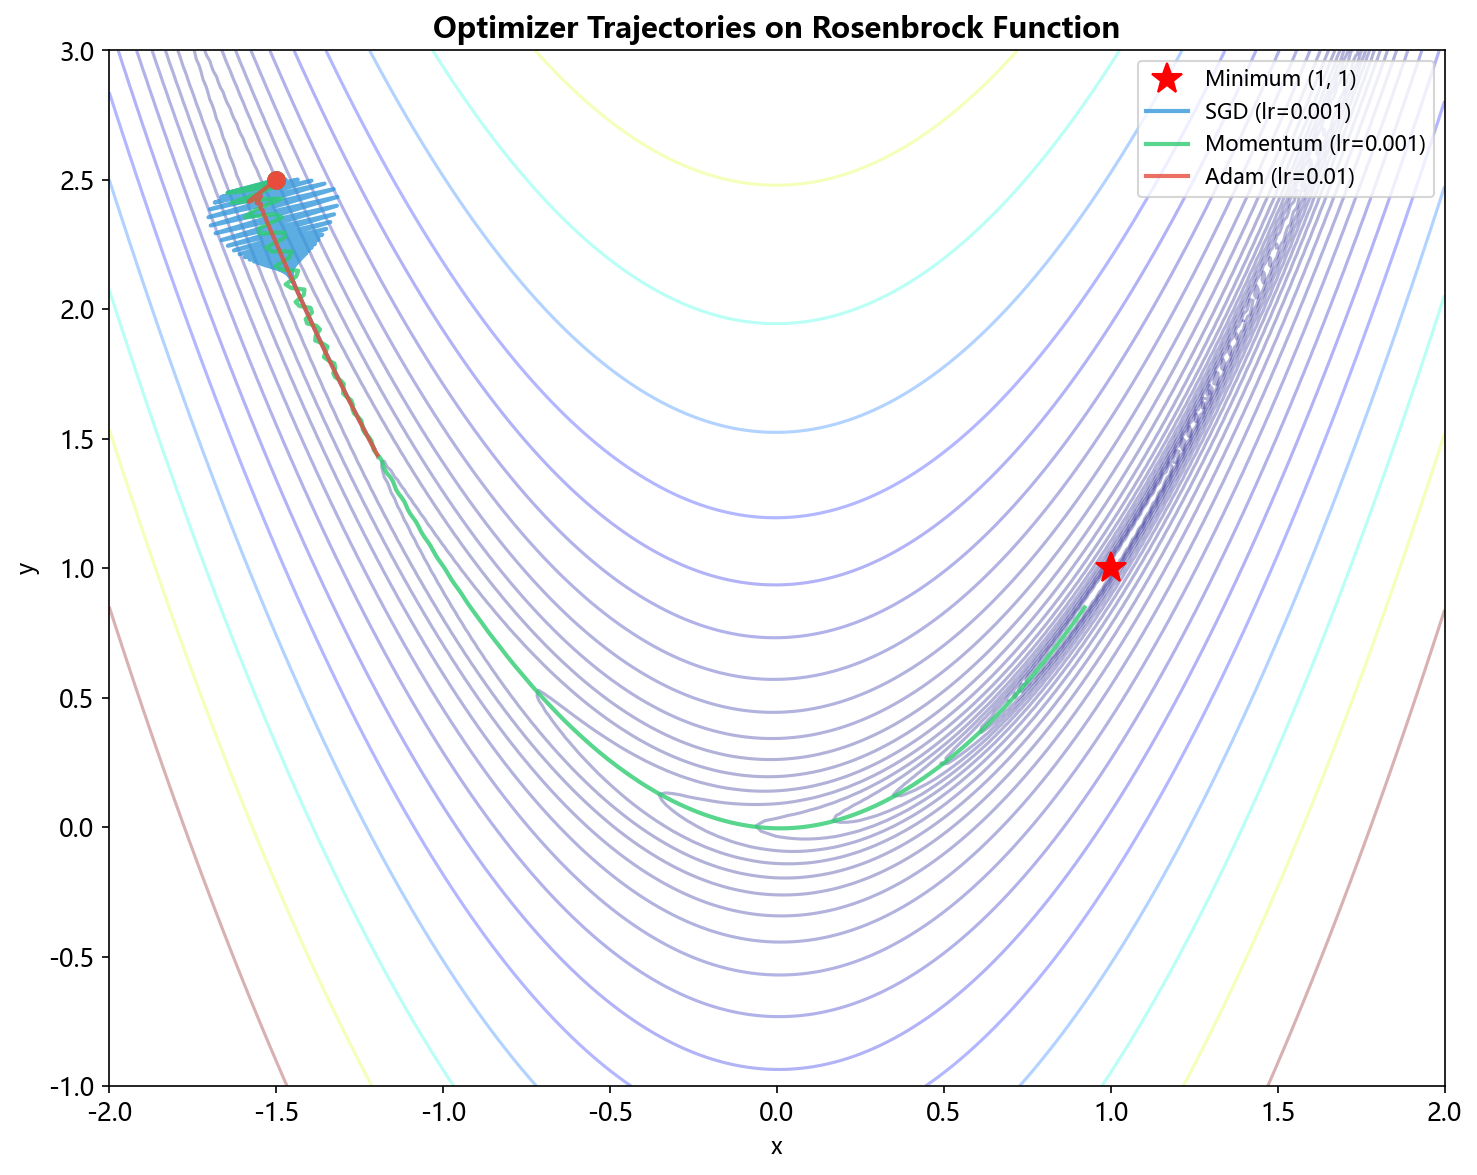

In [23]:
# ============================================================
# Experiment 6: Optimizer Comparison on Rosenbrock Function
# ============================================================

# Rosenbrock function: f(x, y) = (1-x)^2 + 100(y - x^2)^2
# Classic test function with a narrow, curved valley
def rosenbrock(params):
    x, y = params['x'], params['y']
    return (1 - x)**2 + 100 * (y - x**2)**2


def rosenbrock_grad(params):
    x, y = params['x'], params['y']
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return {'x': dx, 'y': dy}


# Run optimizers from same starting point
np.random.seed(42)
optimizers_rosen = {
    'SGD (lr=0.001)': SGD(lr=0.001),
    'Momentum (lr=0.001)': SGDMomentum(lr=0.001, momentum=0.9),
    'Adam (lr=0.01)': Adam(lr=0.01),
}

trajectories = {}
for name, opt in optimizers_rosen.items():
    params = {'x': -1.5, 'y': 2.5}
    path = [(params['x'], params['y'])]
    for _ in range(500):
        grads = rosenbrock_grad(params)
        params = opt.update(params, grads)
        path.append((params['x'], params['y']))
    trajectories[name] = np.array(path)

fig, ax = plt.subplots(figsize=(10, 8))

# Contour plot of Rosenbrock function
X_grid, Y_grid = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-1, 3, 200))
Z = (1 - X_grid)**2 + 100 * (Y_grid - X_grid**2)**2
ax.contour(X_grid, Y_grid, Z, levels=np.logspace(-1, 3, 20), cmap='jet', alpha=0.3)
ax.plot(1, 1, 'r*', markersize=15, label='Minimum (1, 1)')

colors = ['#3498db', '#2ecc71', '#e74c3c']
for (name, traj), color in zip(trajectories.items(), colors):
    ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=2, label=name, alpha=0.8)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=8)

ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_title('Optimizer Trajectories on Rosenbrock Function',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 3)
plt.tight_layout()
fig.savefig(fig_dir + '/optimizer_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved: optimizer_trajectories.png")


Figure 7 saved: convergence_speed.png

Adam converges fastest due to adaptive per-parameter learning rates.
Momentum accelerates SGD but can overshoot in curved valleys.


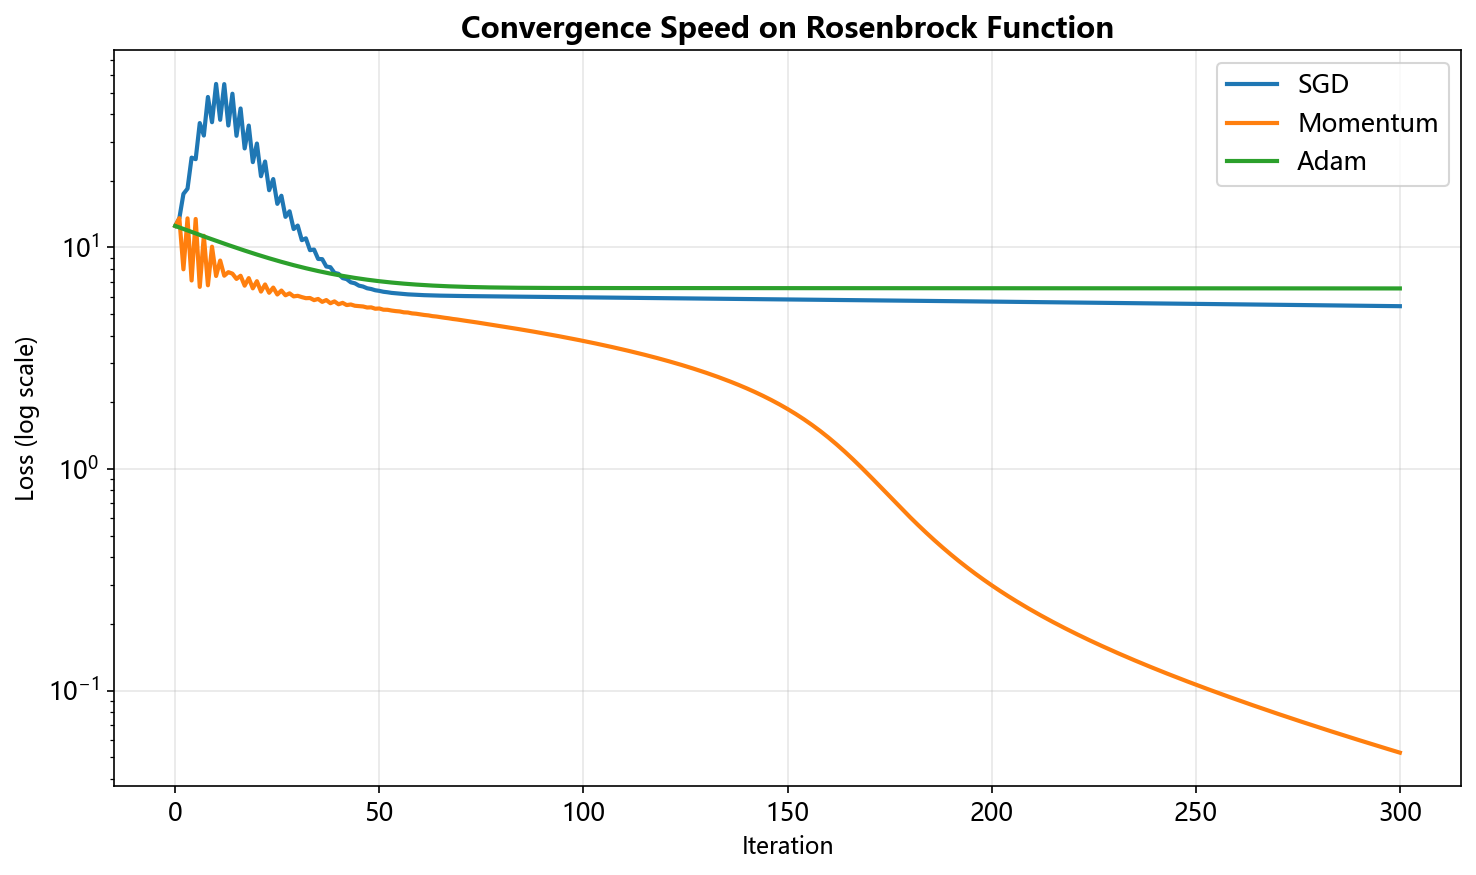

In [24]:
# ============================================================
# Experiment 7: Convergence Speed Comparison
# ============================================================

np.random.seed(42)
optimizers_conv = {
    'SGD': SGD(lr=0.001),
    'Momentum': SGDMomentum(lr=0.001, momentum=0.9),
    'Adam': Adam(lr=0.001),
}

fig, ax = plt.subplots(figsize=(10, 6))

for name, opt in optimizers_conv.items():
    params = {'x': -1.5, 'y': 2.5}
    losses = [rosenbrock(params)]
    for _ in range(300):
        grads = rosenbrock_grad(params)
        params = opt.update(params, grads)
        losses.append(rosenbrock(params))
    ax.plot(losses, linewidth=2, label=name)

ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Loss (log scale)', fontsize=11)
ax.set_title('Convergence Speed on Rosenbrock Function',
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir + '/convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved: convergence_speed.png")
print("\nAdam converges fastest due to adaptive per-parameter learning rates.")
print("Momentum accelerates SGD but can overshoot in curved valleys.")


## 8. 学习率调度策略

### 直觉

训练初期需要大学习率快速接近最优点，后期需要小学习率精细调整。学习率调度自动管理这一过程。

### 常见策略

**1. 阶梯衰减 (Step Decay)**：每 N 个 epoch 将学习率乘以 gamma
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / N \rfloor}$$

**2. 指数衰减 (Exponential Decay)**：
$$\eta_t = \eta_0 \cdot e^{-\lambda t}$$

**3. 余弦退火 (Cosine Annealing)**：
$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_0 - \eta_{min}) \cdot (1 + \cos(\frac{\pi t}{T}))$$

**4. Warmup + 余弦退火**：先线性增大再余弦减小（Transformer 标准配置）

**手动计算（阶梯衰减）：** $\eta_0 = 0.1, \gamma = 0.5, N = 10$
- epoch 0-9: $\eta = 0.1$
- epoch 10-19: $\eta = 0.05$
- epoch 20-29: $\eta = 0.025$

**参考论文：**
- [[Loshchilov and Hutter, 2017]](https://arxiv.org/abs/1608.03983) - SGDR
- [[Smith, 2017]](https://arxiv.org/abs/1704.04289) - Cyclical LR


Figure 8 saved: lr_schedules.png


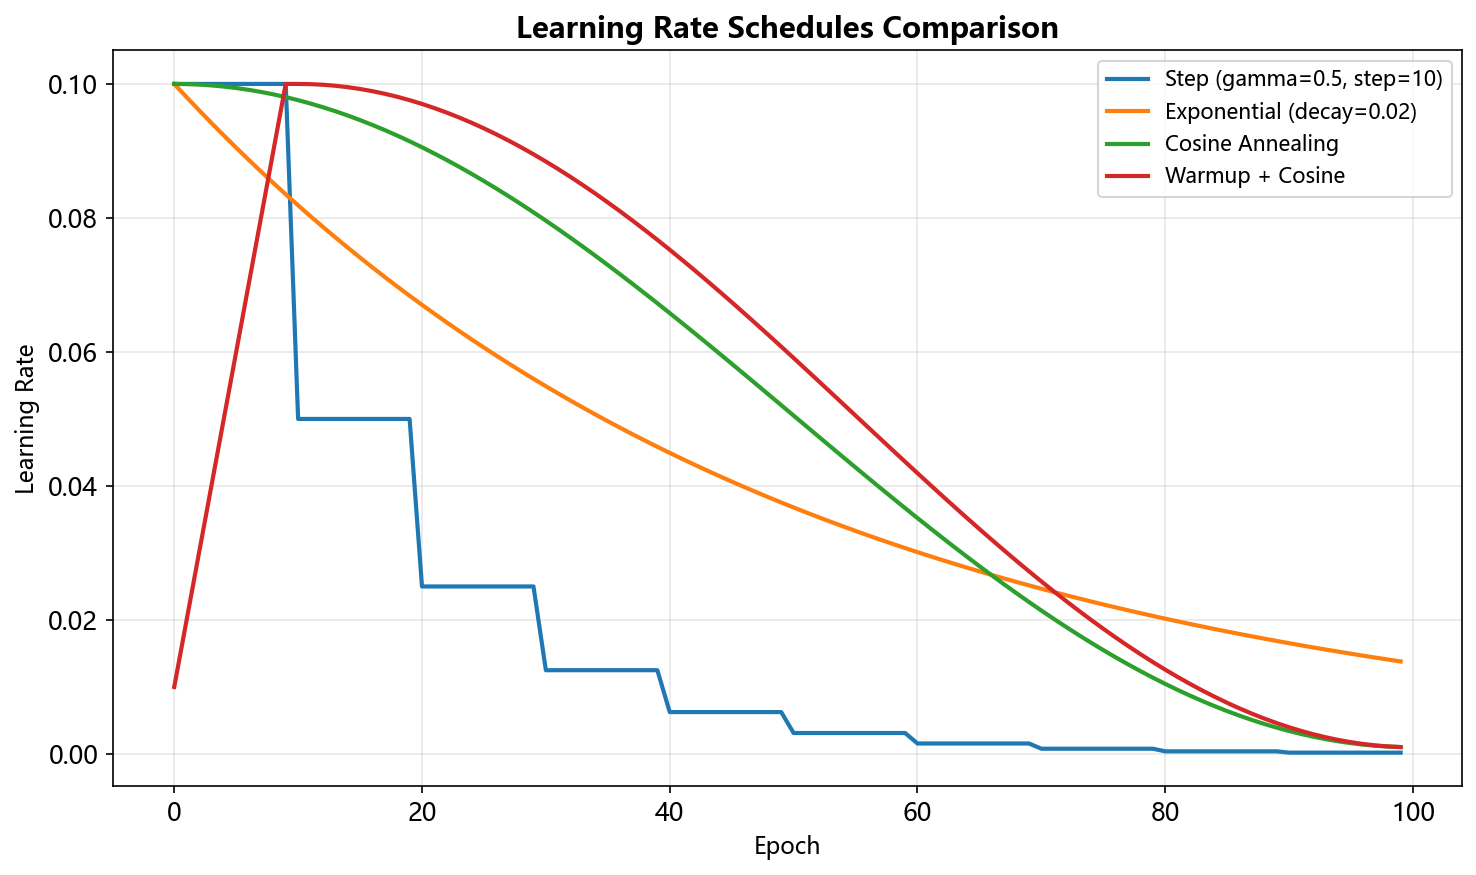

In [26]:
# ============================================================
# Learning Rate Schedulers
# ============================================================

class StepLR:
    """Step decay learning rate scheduler."""

    def __init__(self, lr0=0.1, step_size=10, gamma=0.5):
        self.lr0 = lr0
        self.step_size = step_size
        self.gamma = gamma

    def get_lr(self, epoch):
        return self.lr0 * (self.gamma ** (epoch // self.step_size))


class ExponentialLR:
    """Exponential decay learning rate scheduler."""

    def __init__(self, lr0=0.1, decay=0.01):
        self.lr0 = lr0
        self.decay = decay

    def get_lr(self, epoch):
        return self.lr0 * np.exp(-self.decay * epoch)


class CosineAnnealingLR:
    """Cosine annealing learning rate scheduler."""

    def __init__(self, lr0=0.1, lr_min=0.001, T=100):
        self.lr0 = lr0
        self.lr_min = lr_min
        self.T = T

    def get_lr(self, epoch):
        return self.lr_min + 0.5 * (self.lr0 - self.lr_min) * (
            1 + np.cos(np.pi * epoch / self.T))


class WarmupCosineLR:
    """Linear warmup + cosine annealing."""

    def __init__(self, lr0=0.1, lr_min=0.001, T=100, warmup=10):
        self.lr0 = lr0
        self.lr_min = lr_min
        self.T = T
        self.warmup = warmup

    def get_lr(self, epoch):
        if epoch < self.warmup:
            return self.lr0 * (epoch + 1) / self.warmup
        return self.lr_min + 0.5 * (self.lr0 - self.lr_min) * (
            1 + np.cos(np.pi * (epoch - self.warmup) / (self.T - self.warmup)))


# Visualize all schedules
schedulers = {
    'Step (gamma=0.5, step=10)': StepLR(lr0=0.1, step_size=10, gamma=0.5),
    'Exponential (decay=0.02)': ExponentialLR(lr0=0.1, decay=0.02),
    'Cosine Annealing': CosineAnnealingLR(lr0=0.1, lr_min=0.001, T=100),
    'Warmup + Cosine': WarmupCosineLR(lr0=0.1, lr_min=0.001, T=100, warmup=10),
}

fig, ax = plt.subplots(figsize=(10, 6))
epochs = np.arange(100)

for name, sched in schedulers.items():
    lrs = [sched.get_lr(e) for e in epochs]
    ax.plot(epochs, lrs, linewidth=2, label=name)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('Learning Rate Schedules Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir + '/lr_schedules.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved: lr_schedules.png")


## 9. 梯度检验 (Gradient Checking)

### 直觉

梯度检验通过数值方法验证解析梯度的正确性。核心思想是使用有限差分近似梯度，然后与反向传播计算的梯度比较。

这是调试反向传播代码的黄金标准！

### 手动计算

**数值梯度（中心差分法）：**
$$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$$

前向差分 $\frac{f(x+h) - f(x)}{h}$ 的误差是 $O(h)$，
中心差分的误差是 $O(h^2)$，精度更高。

**相对误差：**
$$\text{rel\_error} = \frac{\|g_{\text{analytic}} - g_{\text{numerical}}\|}{\|g_{\text{analytic}}\| + \|g_{\text{numerical}}\|}$$

**判定标准：**
- 相对误差 $< 10^{-7}$：梯度正确
- 相对误差在 $10^{-4} \sim 10^{-7}$：可能正确，需检查特殊情况
- 相对误差 $> 10^{-4}$：梯度可能有误

**数值示例：** $f(x) = x^2, x = 3.0, h = 0.001$
- 解析梯度: $f'(3) = 2 \times 3 = 6.0$
- 数值梯度: $(3.001^2 - 2.999^2) / 0.002 = (9.006001 - 8.994001) / 0.002 = 6.0$
- 相对误差: 0 （完美！）


In [28]:
# ============================================================
# Gradient Checking Implementation
# ============================================================

def numerical_gradient(f, x, h=1e-5):
    """
    Compute numerical gradient using central difference.
    f: scalar function
    x: input array
    h: perturbation size
    """
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        old_val = x[idx]
        x[idx] = old_val + h
        fx_plus = f(x)
        x[idx] = old_val - h
        fx_minus = f(x)
        x[idx] = old_val
        grad[idx] = (fx_plus - fx_minus) / (2 * h)
        it.iternext()
    return grad


def rel_error(x, y):
    """Compute relative error between two arrays."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


# Test: quadratic function f(x) = sum(x^2)
np.random.seed(42)
x = np.random.randn(5, 5)
f = lambda x: np.sum(x ** 2)
analytic_grad = 2 * x
numerical_grad = numerical_gradient(f, x.copy())

print("=== Gradient Check: f(x) = sum(x^2) ===")
print(f"Analytic grad sample: {analytic_grad[0, :3]}")
print(f"Numerical grad sample: {numerical_grad[0, :3]}")
error = rel_error(analytic_grad, numerical_grad)
print(f"Relative error: {error:.2e}")
print(f"Pass threshold (< 1e-7): {error < 1e-7}")


=== Gradient Check: f(x) = sum(x^2) ===
Analytic grad sample: [ 0.99342831 -0.2765286   1.29537708]
Numerical grad sample: [ 0.99342831 -0.2765286   1.29537708]
Relative error: 4.43e-10
Pass threshold (< 1e-7): True


In [29]:
# ============================================================
# Gradient Check: Softmax Loss w.r.t. Weights
# ============================================================

np.random.seed(42)
N, D, C = 20, 10, 3  # 20 samples, 10 features, 3 classes
X = np.random.randn(N, D)
W = np.random.randn(D, C)
y = np.random.randint(0, C, N)

# --- Analytic gradient ---
scores = X @ W
shifted = scores - np.max(scores, axis=1, keepdims=True)
exp_scores = np.exp(shifted)
probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
loss_val = -np.sum(np.log(probs[np.arange(N), y] + 1e-12)) / N
dscores = probs.copy()
dscores[np.arange(N), y] -= 1
dscores /= N
dW_analytic = X.T @ dscores

# --- Numerical gradient ---
def softmax_loss_w(W_param):
    s = X @ W_param
    s = s - s.max(axis=1, keepdims=True)
    p = np.exp(s) / np.exp(s).sum(axis=1, keepdims=True)
    return -np.sum(np.log(p[np.arange(N), y] + 1e-12)) / N

dW_numerical = numerical_gradient(softmax_loss_w, W.copy())

print("=== Gradient Check: Softmax Loss w.r.t. W ===")
print(f"Loss value: {loss_val:.6f}")
error_w = rel_error(dW_analytic, dW_numerical)
print(f"Relative error (W): {error_w:.2e}")
print(f"Pass threshold (< 1e-7): {error_w < 1e-7}")


=== Gradient Check: Softmax Loss w.r.t. W ===
Loss value: 2.749023
Relative error (W): 7.58e-08
Pass threshold (< 1e-7): True


In [30]:
# ============================================================
# Gradient Check: BatchNorm Backward Pass
# ============================================================

np.random.seed(42)
N_bn, D_bn = 8, 5
x_bn = np.random.randn(N_bn, D_bn)
gamma_bn = np.random.randn(D_bn)
beta_bn = np.random.randn(D_bn)
dout_bn = np.random.randn(N_bn, D_bn)

bn_test = BatchNorm(D_bn)
bn_test.gamma = gamma_bn.copy()
bn_test.beta = beta_bn.copy()

# Analytic backward
out_bn = bn_test.forward(x_bn, training=True)
dx_analytic, dgamma_analytic, dbeta_analytic = bn_test.backward(x_bn, dout_bn)

# Numerical gradient w.r.t. x
def bn_loss_x(x_param):
    bn_temp = BatchNorm(D_bn)
    bn_temp.gamma = gamma_bn
    bn_temp.beta = beta_bn
    return np.sum(bn_temp.forward(x_param, training=True) * dout_bn)

dx_num = numerical_gradient(bn_loss_x, x_bn.copy(), h=1e-6)

# Numerical gradient w.r.t. gamma
def bn_loss_gamma(g_param):
    bn_temp = BatchNorm(D_bn)
    bn_temp.gamma = g_param
    bn_temp.beta = beta_bn
    return np.sum(bn_temp.forward(x_bn, training=True) * dout_bn)

dgamma_num = numerical_gradient(bn_loss_gamma, gamma_bn.copy(), h=1e-6)

print("=== Gradient Check: BatchNorm ===")
error_dx = rel_error(dx_analytic, dx_num)
error_dgamma = rel_error(dgamma_analytic, dgamma_num)
print(f"dx relative error:     {error_dx:.2e}")
print(f"dgamma relative error: {error_dgamma:.2e}")
print(f"All pass (< 1e-6): {error_dx < 1e-6 and error_dgamma < 1e-6}")


=== Gradient Check: BatchNorm ===
dx relative error:     1.75e-08
dgamma relative error: 7.45e-10
All pass (< 1e-6): True


## 10. 训练合理性检查 (Sanity Checks)

### 为什么需要合理性检查？

在实际训练大数据集之前，先用几个小实验验证代码正确性。这能节省大量调试时间！

### 训练前检查清单

1. **初始损失检查**：初始损失应接近随机猜测的损失 $-\log(1/C)$
2. **过拟合小批量数据**：在少量样本上应该能达到接近零的损失
3. **初始化检查**：激活值不应全部为零或爆炸
4. **梯度范围检查**：各层梯度量级不应相差太大
5. **监控训练曲线**：loss 应该下降，acc 应该上升

### 手动验证

对于 C=10 的分类问题：
- 随机猜测的期望损失 = $-\log(1/10) = \ln(10) \approx 2.303$
- 如果初始损失远大于 2.303，可能初始化有问题
- 如果训练 10 个样本 1000 次迭代后损失不下降，一定有 bug
- 如果损失能降到接近 0，说明前向和反向传播基本正确


In [32]:
# ============================================================
# Sanity Check 1: Initial Loss Should Be ~ln(C)
# ============================================================

np.random.seed(42)
N, D, C = 50, 20, 10
X_sc = np.random.randn(N, D)
# Small initialization (common before people knew about He init)
W_sc = init_small_normal(D, C, std=0.01)
y_sc = np.random.randint(0, C, N)

scores = X_sc @ W_sc
shifted = scores - scores.max(axis=1, keepdims=True)
probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
initial_loss = -np.sum(np.log(probs[np.arange(N), y_sc] + 1e-12)) / N

expected_loss = -np.log(1.0 / C)

print("=== Sanity Check 1: Initial Loss ===")
print(f"Number of classes: {C}")
print(f"Expected (random) loss: -ln(1/{C}) = {expected_loss:.4f}")
print(f"Actual initial loss:   {initial_loss:.4f}")
ratio = initial_loss / expected_loss
print(f"Ratio (should be ~1.0): {ratio:.4f}")
print(f"Check: {'PASS' if 0.9 < ratio < 1.1 else 'FAIL - investigate initialization'}")


=== Sanity Check 1: Initial Loss ===
Number of classes: 10
Expected (random) loss: -ln(1/10) = 2.3026
Actual initial loss:   2.3028
Ratio (should be ~1.0): 1.0001
Check: PASS


Figure 9 saved: sanity_overfit.png

Initial loss: 1.6758
Final loss:   0.000881
Loss ratio: 1902.2x reduction
Overfit small batch: PASS


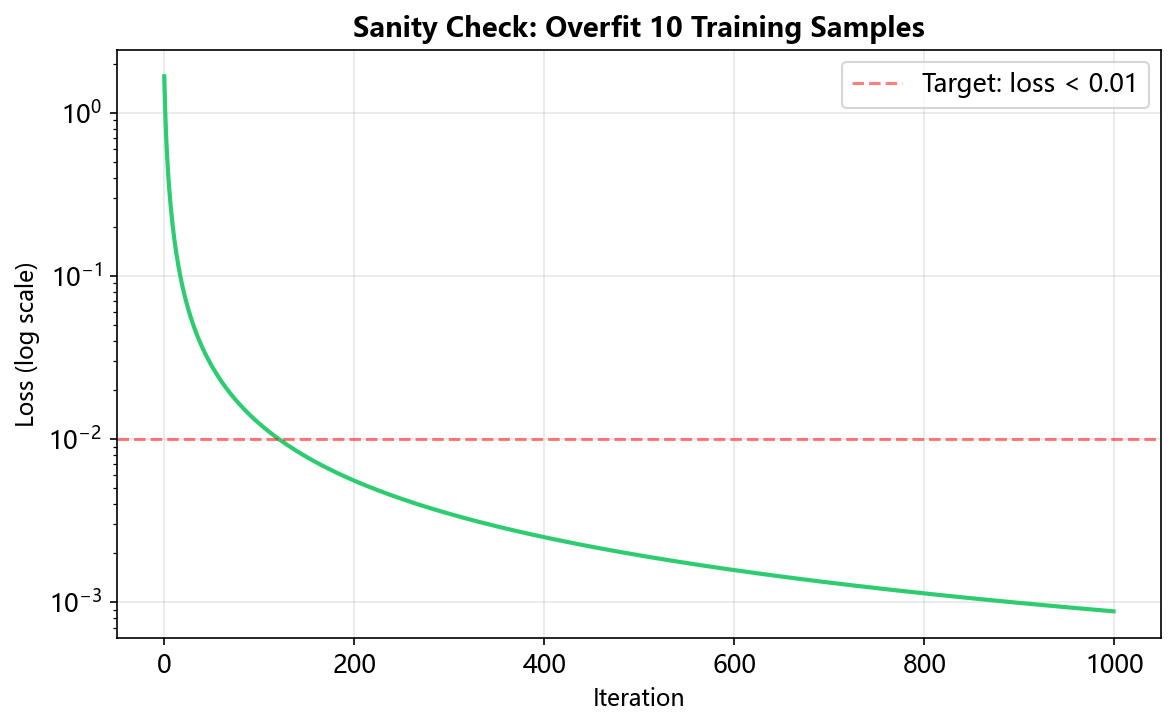

In [33]:
# ============================================================
# Sanity Check 2: Overfit a Small Batch
# ============================================================

np.random.seed(42)
N_small, D_s, H_s, C_s = 10, 20, 64, 3
X_small = np.random.randn(N_small, D_s)
y_small = np.random.randint(0, C_s, N_small)

# Initialize a 2-layer network
W1_s = init_he_normal(D_s, H_s)
b1_s = np.zeros(H_s)
W2_s = init_he_normal(H_s, C_s)
b2_s = np.zeros(C_s)

losses_sanity = []
lr = 0.1

for epoch in range(1000):
    # Forward
    h = relu(X_small @ W1_s + b1_s)
    scores = h @ W2_s + b2_s
    shifted = scores - scores.max(axis=1, keepdims=True)
    probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
    loss = -np.sum(np.log(probs[np.arange(N_small), y_small] + 1e-12)) / N_small
    losses_sanity.append(loss)

    # Backward
    dscores = probs.copy()
    dscores[np.arange(N_small), y_small] -= 1
    dscores /= N_small
    dW2 = h.T @ dscores
    db2 = dscores.sum(axis=0)
    dh = dscores @ W2_s.T
    dW1 = X_small.T @ (dh * (h > 0))
    db1 = (dh * (h > 0)).sum(axis=0)

    # Update
    W1_s -= lr * dW1
    b1_s -= lr * db1
    W2_s -= lr * dW2
    b2_s -= lr * db2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses_sanity, linewidth=2, color='#2ecc71')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Loss (log scale)', fontsize=11)
ax.set_title('Sanity Check: Overfit 10 Training Samples',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.01, color='r', linestyle='--', alpha=0.5, label='Target: loss < 0.01')
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir + '/sanity_overfit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 9 saved: sanity_overfit.png")
print(f"\nInitial loss: {losses_sanity[0]:.4f}")
print(f"Final loss:   {losses_sanity[-1]:.6f}")
print(f"Loss ratio: {losses_sanity[0] / max(losses_sanity[-1], 1e-10):.1f}x reduction")
passed = losses_sanity[-1] < 0.01
print(f"Overfit small batch: {'PASS' if passed else 'FAIL'}")


## 11. Dropout 正则化

### 直觉

Dropout 在训练时随机「丢弃」一部分神经元（将其输出置零），迫使网络不能依赖任何单个特征，从而减少过拟合。

可以理解为训练了一个「集成模型」——每次迭代相当于训练一个不同的子网络。

### 手动计算

**训练阶段：**
- 输入 $x \in \mathbb{R}^n$，dropout 概率 $p$
- 生成掩码 $m \sim \text{Bernoulli}(p)$（每个元素以概率 $p$ 为 1）
- 输出 $y = x \odot m / p$（除以 $p$ 称为「Inverted Dropout」，保证测试时无需缩放）

**测试阶段：**
- 不使用 dropout，直接使用所有神经元
- 由于 inverted dropout，测试时输出自动具有正确的期望

**数值示例：** $x = [1.0, 2.0, 3.0, 4.0], p = 0.5$
- 随机掩码: $m = [1, 0, 1, 0]$
- 训练输出: $y = [1.0/0.5, 0, 3.0/0.5, 0] = [2.0, 0, 6.0, 0]$
- 测试输出: $y = [1.0, 2.0, 3.0, 4.0]$（期望一致）

**参考论文：** [[Srivastava et al., 2014]](https://jmlr.org/papers/v15/srivastava14a.html)


In [35]:
# ============================================================
# Dropout Implementation
# ============================================================

class Dropout:
    """Inverted Dropout layer."""

    def __init__(self, p=0.5):
        self.p = p  # probability of keeping a neuron
        self.mask = None

    def forward(self, x, training=True):
        """Forward pass."""
        if training:
            # Generate mask and scale by 1/p (inverted dropout)
            self.mask = (np.random.rand(*x.shape) < self.p).astype(float)
            return x * self.mask / self.p
        else:
            return x  # no scaling needed in test with inverted dropout

    def backward(self, dout):
        """Backward pass."""
        return dout * self.mask / self.p


# Test Dropout
np.random.seed(42)
dropout = Dropout(p=0.5)
x_drop = np.random.randn(5, 10)
out_train = dropout.forward(x_drop, training=True)
out_test = dropout.forward(x_drop, training=False)

print("=== Dropout Test ===")
print(f"Input shape: {x_drop.shape}")
print(f"Training output - mean: {out_train.mean():.4f}, std: {out_train.std():.4f}")
print(f"Test output     - mean: {out_test.mean():.4f}, std: {out_test.std():.4f}")
print(f"Fraction of zeros in train output: {(out_train == 0).mean():.2%}")
print(f"Expected fraction: {1 - dropout.p:.0%}")
print("\nKey insight: Inverted dropout preserves the expected output magnitude.")


=== Dropout Test ===
Input shape: (5, 10)
Training output - mean: -0.1918, std: 1.3178
Test output     - mean: -0.2255, std: 0.9243
Fraction of zeros in train output: 50.00%
Expected fraction: 50%

Key insight: Inverted dropout preserves the expected output magnitude.


## 12. AdamW 与解耦权重衰减

### 直觉

权重衰减（L2 正则化）通过在损失函数中添加权重平方和的惩罚项，防止过拟合：
$$L_{\text{total}} = L_{\text{data}} + \lambda \sum W^2$$

但在 Adam 中，L2 正则化和权重衰减不等价！这是因为自适应学习率会「稀释」正则化效果。

**AdamW** 将权重衰减与梯度更新解耦：
- 标准 Adam + L2：梯度中包含正则化项，受自适应学习率影响
- AdamW：权重衰减独立于梯度更新，直接乘到参数上

### 手动计算

**AdamW 更新：**
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_{t+1} = \theta_t - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \text{wd} \cdot \theta_t \right)$$

注意权重衰减项 $\text{wd} \cdot \theta_t$ 是独立加到更新上的，不经过自适应缩放。

**参考论文：** [[Loshchilov and Hutter, 2019]](https://arxiv.org/abs/1711.05101)


Figure 10 saved: adamw_comparison.png

Final weight norm - Adam:   11.3519
Final weight norm - AdamW:  10.3033
AdamW steadily reduces weight norm via decoupled decay.


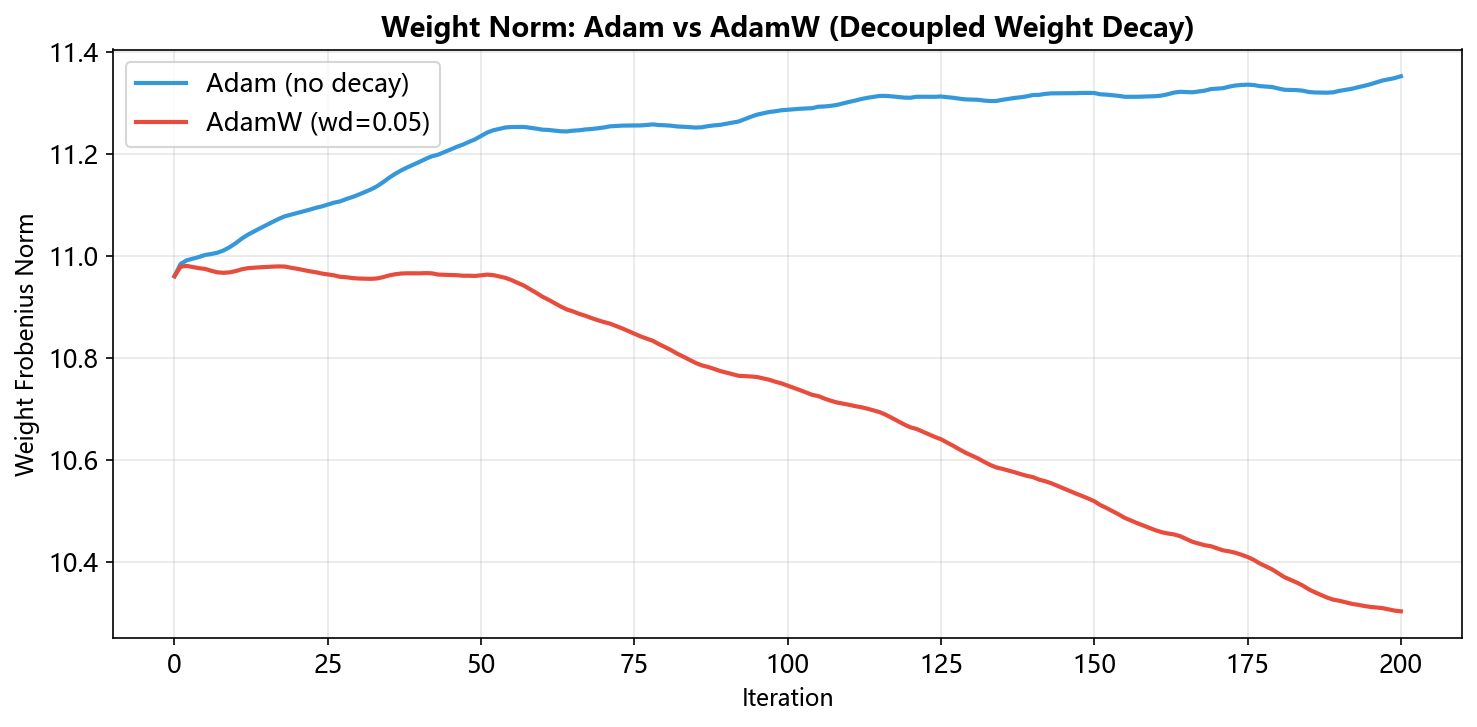

In [37]:
# ============================================================
# AdamW Implementation and Comparison
# ============================================================

class AdamW:
    """Adam with decoupled weight decay."""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = {}
        self.v = {}
        self.t = 0

    def update(self, params, grads):
        self.t += 1
        for k in params:
            if k not in self.m:
                self.m[k] = np.zeros_like(params[k])
                self.v[k] = np.zeros_like(params[k])
            # Update biased moment estimates
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            # Bias correction
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            # Decoupled weight decay
            params[k] -= self.lr * (m_hat / (np.sqrt(v_hat) + self.eps)
                                    + self.weight_decay * params[k])
        return params


# Compare weight norms: Adam (no decay) vs AdamW
np.random.seed(42)
W_adam = np.random.randn(50, 10) * 0.5
W_adamw = W_adam.copy()
adam = Adam(lr=0.01)
adamw = AdamW(lr=0.01, weight_decay=0.05)

norms_adam = [np.linalg.norm(W_adam)]
norms_adamw = [np.linalg.norm(W_adamw)]

for _ in range(200):
    # Simulate gradient (random noise + small signal)
    grad = np.random.randn(50, 10) * 0.05 + 0.01 * np.random.randn(50, 10)
    params_a = {'W': W_adam}
    params_w = {'W': W_adamw}
    params_a = adam.update(params_a, {'W': grad})
    params_w = adamw.update(params_w, {'W': grad})
    W_adam = params_a['W']
    W_adamw = params_w['W']
    norms_adam.append(np.linalg.norm(W_adam))
    norms_adamw.append(np.linalg.norm(W_adamw))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norms_adam, label='Adam (no decay)', linewidth=2, color='#3498db')
ax.plot(norms_adamw, label='AdamW (wd=0.05)', linewidth=2, color='#e74c3c')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Weight Frobenius Norm', fontsize=11)
ax.set_title('Weight Norm: Adam vs AdamW (Decoupled Weight Decay)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir + '/adamw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved: adamw_comparison.png")
print(f"\nFinal weight norm - Adam:   {norms_adam[-1]:.4f}")
print(f"Final weight norm - AdamW:  {norms_adamw[-1]:.4f}")
print("AdamW steadily reduces weight norm via decoupled decay.")


## 13. 综合实验：完整训练流程

现在我们将上述所有技术整合，在一个完整的训练流程中对比不同配置的效果。

**数据集：** 合成螺旋二分类数据（非线性可分）
**对比配置：**
- SGD + He 初始化
- Momentum + He 初始化
- Adam + He 初始化
- Adam + Xavier 初始化


Figure (extra) saved: full_training_pipeline.png

Final results:
  SGD + He            : loss=0.8515, acc=0.5900
  Momentum + He       : loss=0.6257, acc=0.6500
  Adam + He           : loss=0.4152, acc=0.8400
  Adam + Xavier       : loss=0.0685, acc=0.9967


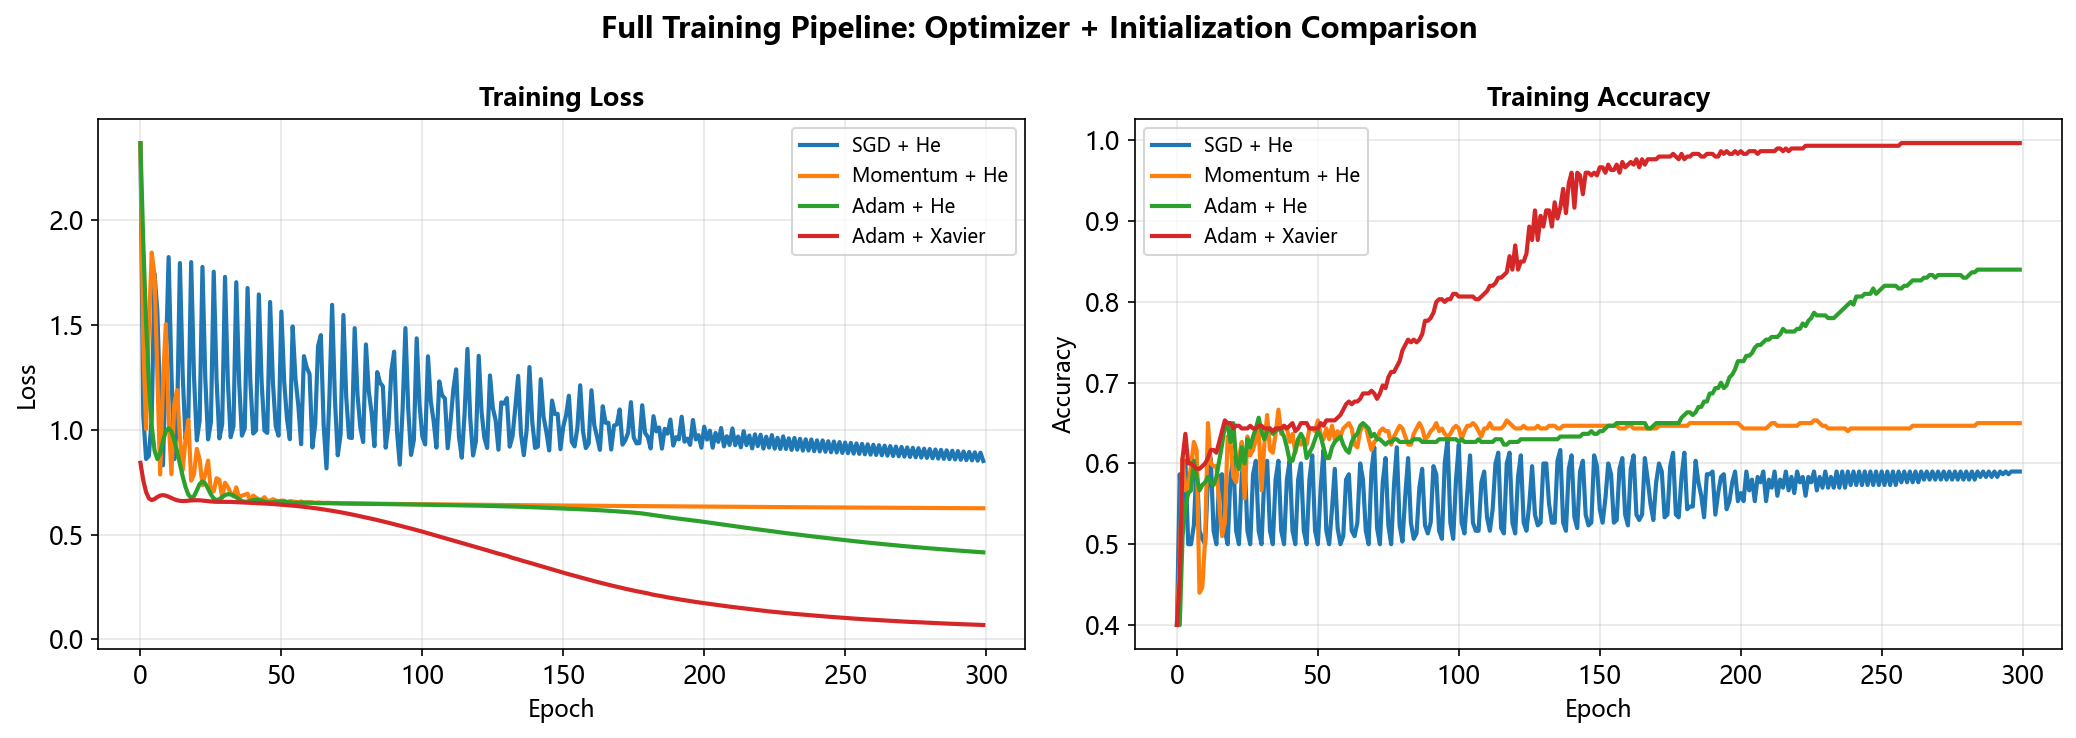

In [39]:
# ============================================================
# Comprehensive Experiment: Full Training Pipeline
# ============================================================

np.random.seed(42)

# Generate synthetic 2-class spiral dataset
N = 300
r = np.linspace(0, 5, N // 2)
theta1 = np.linspace(0, 3 * np.pi, N // 2) + np.random.randn(N // 2) * 0.3
theta2 = np.linspace(0, 3 * np.pi, N // 2) + np.pi + np.random.randn(N // 2) * 0.3
X1 = np.stack([r * np.cos(theta1), r * np.sin(theta1)], axis=1)
X2 = np.stack([r * np.cos(theta2), r * np.sin(theta2)], axis=1)
X_data = np.vstack([X1, X2])
y_data = np.array([0] * len(X1) + [1] * len(X2))
idx = np.random.permutation(N)
X_data, y_data = X_data[idx], y_data[idx]

D_net, H_net, C_net = 2, 64, 2

configs_full = {
    'SGD + He': {'opt_cls': SGD, 'opt_kwargs': {'lr': 0.1}, 'init': 'he'},
    'Momentum + He': {'opt_cls': SGDMomentum, 'opt_kwargs': {'lr': 0.05, 'momentum': 0.9}, 'init': 'he'},
    'Adam + He': {'opt_cls': Adam, 'opt_kwargs': {'lr': 0.01}, 'init': 'he'},
    'Adam + Xavier': {'opt_cls': Adam, 'opt_kwargs': {'lr': 0.01}, 'init': 'xavier'},
}

results = {}

for name, cfg in configs_full.items():
    np.random.seed(42)
    init_fn = init_he_normal if cfg['init'] == 'he' else init_xavier_normal
    W1 = init_fn(D_net, H_net)
    W2 = init_fn(H_net, C_net)
    b1 = np.zeros(H_net)
    b2 = np.zeros(C_net)
    opt = cfg['opt_cls'](**cfg['opt_kwargs'])
    params = {'W1': W1, 'W2': W2, 'b1': b1, 'b2': b2}
    losses_list = []
    accs_list = []

    for epoch in range(300):
        # Forward pass
        h = relu(X_data @ params['W1'] + params['b1'])
        scores = h @ params['W2'] + params['b2']
        shifted = scores - scores.max(axis=1, keepdims=True)
        probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
        loss = -np.sum(np.log(probs[np.arange(N), y_data] + 1e-12)) / N
        losses_list.append(loss)

        # Accuracy
        pred = scores.argmax(axis=1)
        acc = (pred == y_data).mean()
        accs_list.append(acc)

        # Backward pass
        dscores = probs.copy()
        dscores[np.arange(N), y_data] -= 1
        dscores /= N
        grads = {
            'W2': h.T @ dscores,
            'b2': dscores.sum(axis=0),
            'W1': X_data.T @ (dscores @ params['W2'].T * (h > 0)),
            'b1': (dscores @ params['W2'].T * (h > 0)).sum(axis=0),
        }
        params = opt.update(params, grads)

    results[name] = {'loss': losses_list, 'acc': accs_list}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    axes[0].plot(res['loss'], linewidth=2, label=name)
    axes[1].plot(res['acc'], linewidth=2, label=name)

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training Loss', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Training Accuracy', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Full Training Pipeline: Optimizer + Initialization Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(fig_dir + '/full_training_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure (extra) saved: full_training_pipeline.png")
print("\nFinal results:")
for name, res in results.items():
    print(f"  {name:20s}: loss={res['loss'][-1]:.4f}, acc={res['acc'][-1]:.4f}")


## 14. 关键要点总结

| 技术 | 核心思想 | 适用场景 |
|---|---|---|
| Xavier 初始化 | 保持方差 $\approx 2/(n_{in}+n_{out})$ | tanh / sigmoid 网络 |
| He 初始化 | 方差 $= 2/n_{in}$ 补偿 ReLU | ReLU 网络（最常用） |
| 批归一化 | 标准化每层输入，加可学习缩放平移 | 深层网络，加速训练 |
| 动量法 | 积累历史梯度方向，加速收敛 | 优化曲面有噪声/曲率 |
| Adam | 自适应每参数学习率 + 动量 | 通用首选，快速原型 |
| AdamW | 解耦权重衰减，正则化效果更好 | 现代 Transformer 标配 |
| 梯度检验 | 数值验证解析梯度 | 调试阶段必做 |
| 学习率调度 | 训练后期降低学习率 | 精细调优 |
| Dropout | 随机丢弃神经元，防止过拟合 | 全连接层正则化 |
| 合理性检查 | 过拟合小批量验证 | 训练前必做 |

**经验法则：**
1. 总是先用 Adam(lr=0.001) 快速原型验证
2. 深层网络使用 He 初始化 + ReLU + BatchNorm
3. 训练前执行合理性检查（初始损失 + 过拟合小批量）
4. 使用余弦退火 + warmup 调度学习率
5. 过拟合时加 Dropout 和权重衰减


## 15. 作业练习

### 作业 1：实现 RMSProp 优化器

RMSProp 是对 Adagrad 的改进，使用指数加权移动平均代替累积平方梯度：

$$v_t = \rho \cdot v_{t-1} + (1 - \rho) \cdot g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t} + \epsilon} \cdot g_t$$

**要求：**
1. 实现 RMSProp 类
2. 在 Rosenbrock 函数上测试
3. 通过下面的 assert 验证


In [42]:
# ============================================================
# Homework 1: Implement RMSProp
# ============================================================

class RMSProp:
    """RMSProp optimizer."""

    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        """
        Args:
            lr: learning rate
            rho: decay rate for moving average of squared gradients
            eps: small constant for numerical stability
        """
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.v = {}  # moving average of squared gradients

    def update(self, params, grads):
        """Update parameters using RMSProp."""
        # TODO: Implement RMSProp update
        # 1. Initialize self.v[k] if not present
        # 2. Update moving average of squared gradients
        # 3. Update parameters
        for k in params:
            if k not in self.v:
                self.v[k] = np.zeros_like(params[k])
            self.v[k] = self.rho * self.v[k] + (1 - self.rho) * (grads[k] ** 2)
            params[k] -= self.lr * grads[k] / (np.sqrt(self.v[k]) + self.eps)
        return params


# ===== Validation Tests =====
np.random.seed(42)

# Test 1: Basic update shape and direction
params_test = {'w': np.array([1.0, 2.0, 3.0])}
grads_test = {'w': np.array([0.5, -1.0, 2.0])}
rmsprop = RMSProp(lr=0.01, rho=0.9, eps=1e-8)
params_test = rmsprop.update(params_test, grads_test)

# After first step, v = (1-rho) * g^2, update = -lr * g / (sqrt(v) + eps)
v_expected = (1 - 0.9) * grads_test['w'] ** 2
update_expected = -0.01 * grads_test['w'] / (np.sqrt(v_expected) + 1e-8)
w_expected = np.array([1.0, 2.0, 3.0]) + update_expected

assert np.allclose(params_test['w'], w_expected, atol=1e-10), "RMSProp first step is incorrect!"
print("Test 1 PASSED: First step calculation is correct.")

# Test 2: On a simple quadratic, loss should decrease significantly
np.random.seed(42)
params_rms = {'w': np.random.randn(10) * 2.0}
opt_rms = RMSProp(lr=0.1, rho=0.9)

# f(w) = sum(w^2), grad = 2*w
def quad_loss(p):
    return np.sum(p['w'] ** 2)

def quad_grad(p):
    return {'w': 2 * p['w']}

initial_loss = quad_loss(params_rms)
for _ in range(100):
    g = quad_grad(params_rms)
    params_rms = opt_rms.update(params_rms, g)
final_loss = quad_loss(params_rms)

assert final_loss < initial_loss, "RMSProp should decrease the loss!"
assert final_loss < initial_loss * 0.01, "RMSProp should reduce loss by at least 99%!"
print(f"Test 2 PASSED: Loss decreased from {initial_loss:.4f} to {final_loss:.6f}")

# Test 3: v accumulates correctly over multiple steps
opt_test = RMSProp(lr=0.01, rho=0.9)
p = {'x': np.array([1.0])}
g1 = {'x': np.array([2.0])}
g2 = {'x': np.array([3.0])}
p = opt_test.update(p, g1)
p = opt_test.update(p, g2)
v_expected_2 = 0.9 * (0.1 * 4.0) + 0.1 * 9.0  # 0.9*v1 + 0.1*g2^2

assert np.allclose(opt_test.v['x'], v_expected_2, atol=1e-10), "v accumulation is incorrect!"
print("Test 3 PASSED: Moving average accumulates correctly.")

print("\n=== All RMSProp tests PASSED! ===")


Test 1 PASSED: First step calculation is correct.
Test 2 PASSED: Loss decreased from 26.8490 to 0.018096
Test 3 PASSED: Moving average accumulates correctly.

=== All RMSProp tests PASSED! ===


### 作业 2：实现 Layer Normalization

与 BatchNorm 不同，LayerNorm 在**特征维度**上归一化，而非批次维度：

$$\mu_i = \frac{1}{D}\sum_{d=1}^{D} x_{id}$$
$$\sigma_i^2 = \frac{1}{D}\sum_{d=1}^{D} (x_{id} - \mu_i)^2$$
$$\hat{x}_{id} = \frac{x_{id} - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}}$$
$$y_{id} = \gamma_d \cdot \hat{x}_{id} + \beta_d$$

**要求：**
1. 实现 LayerNorm 类（forward + backward）
2. 通过下面的 assert 验证
3. 用梯度检验验证 backward 实现

**思考：** 为什么 RNN / Transformer 更倾向于使用 LayerNorm 而非 BatchNorm？

**参考论文：** [[Ba et al., 2016]](https://arxiv.org/abs/1607.06450)


In [44]:
# ============================================================
# Homework 2: Implement Layer Normalization
# ============================================================

class LayerNorm:
    """Layer Normalization for fully connected layers."""

    def __init__(self, dim, eps=1e-5):
        self.gamma = np.ones(dim)
        self.beta = np.zeros(dim)
        self.eps = eps

    def forward(self, x):
        """
        Forward pass of LayerNorm.
        Normalizes along the feature (last) dimension.
        Args:
            x: input of shape (N, D)
        Returns:
            y: output of shape (N, D)
        """
        # TODO: Implement LayerNorm forward
        # 1. Compute mean along last axis
        # 2. Compute variance along last axis
        # 3. Normalize
        # 4. Scale and shift with gamma and beta
        self.x = x
        self.mean = x.mean(axis=-1, keepdims=True)
        self.var = x.var(axis=-1, keepdims=True)
        self.x_norm = (x - self.mean) / np.sqrt(self.var + self.eps)
        return self.gamma * self.x_norm + self.beta

    def backward(self, dout):
        """
        Backward pass of LayerNorm.
        Args:
            dout: upstream gradient of shape (N, D)
        Returns:
            dx: gradient w.r.t. input (N, D)
            dgamma: gradient w.r.t. gamma (D,)
            dbeta: gradient w.r.t. beta (D,)
        """
        # TODO: Implement LayerNorm backward
        N, D = dout.shape
        dgamma = (dout * self.x_norm).sum(axis=0)
        dbeta = dout.sum(axis=0)

        dx_norm = dout * self.gamma
        dvar = (dx_norm * (self.x - self.mean) *
                -0.5 * (self.var + self.eps)**(-1.5)).sum(axis=-1, keepdims=True)
        dmean = (dx_norm * (-1.0 / np.sqrt(self.var + self.eps))).sum(axis=-1, keepdims=True)
        dmean += dvar * (-2.0 * (self.x - self.mean)).mean(axis=-1, keepdims=True)
        dx = (dx_norm / np.sqrt(self.var + self.eps)
              + dvar * 2.0 * (self.x - self.mean) / D
              + dmean / D)
        return dx, dgamma, dbeta


# ===== Validation Tests =====
np.random.seed(42)
N_ln, D_ln = 8, 10
x_ln = np.random.randn(N_ln, D_ln)
ln = LayerNorm(D_ln)

# Test 1: Output should have mean ~0 per sample before gamma/beta
out_ln = ln.forward(x_ln)
# With gamma=1, beta=0, each sample should have mean ~0 and std ~1
sample_means = out_ln.mean(axis=1)
sample_stds = out_ln.std(axis=1)

assert np.allclose(sample_means, 0, atol=1e-6), "LayerNorm output per-sample mean should be ~0!"
assert np.allclose(sample_stds, 1, atol=1e-3), "LayerNorm output per-sample std should be ~1!"
print("Test 1 PASSED: Output has correct per-sample mean and std.")

# Test 2: Gradient check for dx
dout_ln = np.random.randn(N_ln, D_ln)
dx_analytic, dgamma_analytic, dbeta_analytic = ln.backward(dout_ln)

def ln_loss_x(x_param):
    ln_temp = LayerNorm(D_ln)
    ln_temp.gamma = ln.gamma
    ln_temp.beta = ln.beta
    return np.sum(ln_temp.forward(x_param) * dout_ln)

dx_num = numerical_gradient(ln_loss_x, x_ln.copy(), h=1e-6)
error_dx = rel_error(dx_analytic, dx_num)

assert error_dx < 1e-5, f"dx gradient check failed! error={error_dx:.2e}"
print(f"Test 2 PASSED: dx gradient check passed (error={error_dx:.2e})")

# Test 3: Gradient check for dgamma
def ln_loss_gamma(g_param):
    ln_temp = LayerNorm(D_ln)
    ln_temp.gamma = g_param
    ln_temp.beta = ln.beta
    return np.sum(ln_temp.forward(x_ln) * dout_ln)

dgamma_num = numerical_gradient(ln_loss_gamma, ln.gamma.copy(), h=1e-6)
error_dgamma = rel_error(dgamma_analytic, dgamma_num)

assert error_dgamma < 1e-5, f"dgamma gradient check failed! error={error_dgamma:.2e}"
print(f"Test 3 PASSED: dgamma gradient check passed (error={error_dgamma:.2e})")

print("\n=== All LayerNorm tests PASSED! ===")


Test 1 PASSED: Output has correct per-sample mean and std.
Test 2 PASSED: dx gradient check passed (error=4.19e-09)
Test 3 PASSED: dgamma gradient check passed (error=1.76e-09)

=== All LayerNorm tests PASSED! ===


### 作业 3：学习率查找器 (Learning Rate Finder)

实现 Leslie Smith 的学习率查找方法：

**算法：**
1. 从极小学习率（如 1e-8）开始
2. 每个 batch 后按指数增大学习率
3. 记录每个学习率对应的 loss
4. 当 loss 开始发散时停止
5. 选择 loss 下降最快的区域对应的学习率

**要求：**
1. 在螺旋数据集上实现 LR Finder
2. 绘制 loss vs learning rate 曲线
3. 通过 assert 验证找到的最佳学习率在合理范围内

**参考论文：** [[Smith, 2017]](https://arxiv.org/abs/1704.04289)


Figure (extra) saved: lr_finder.png
Test 1 PASSED: Recommended LR = 0.0129 is in reasonable range.
Test 2 PASSED: LR finder ran for 163 steps.
Test 3 PASSED: Loss decreased from 2.3689 to 0.6616.

=== All LR Finder tests PASSED! ===


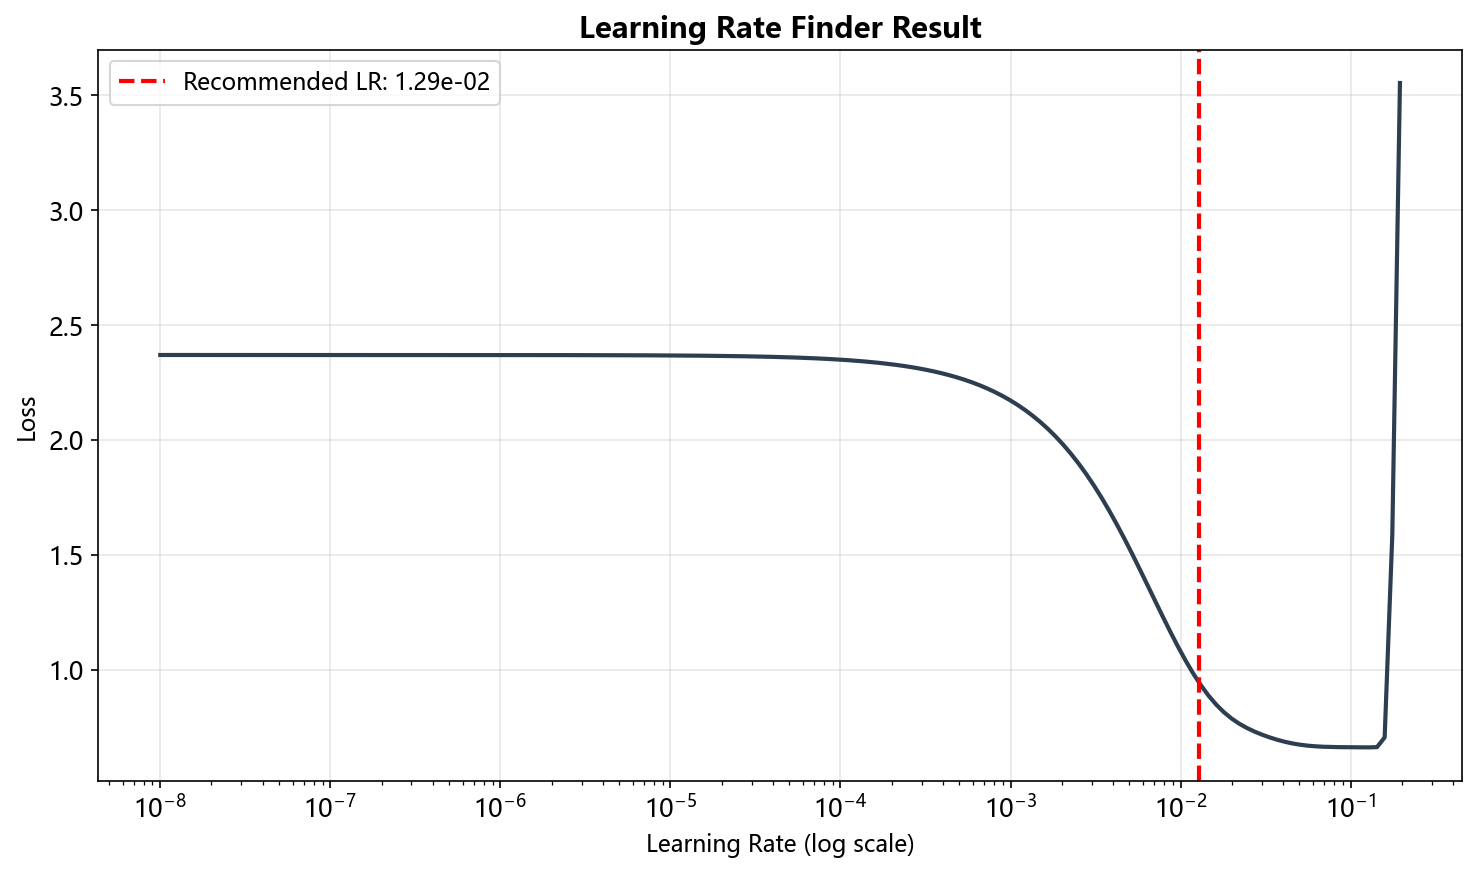

In [46]:
# ============================================================
# Homework 3: Learning Rate Finder
# ============================================================

def lr_finder(X, y, D_in, H, D_out, lr_start=1e-8, lr_end=10.0, n_steps=200):
    """
    Learning rate finder - exponentially increase LR and track loss.

    Args:
        X: input data (N, D_in)
        y: labels (N,)
        D_in: input dimension
        H: hidden layer size
        D_out: number of classes
        lr_start: starting learning rate
        lr_end: ending learning rate
        n_steps: number of steps

    Returns:
        lrs: list of learning rates used
        losses: list of corresponding losses
        best_lr: suggested learning rate (minimum loss / 10)
    """
    np.random.seed(42)
    W1 = init_he_normal(D_in, H)
    W2 = init_he_normal(H, D_out)
    b1 = np.zeros(H)
    b2 = np.zeros(D_out)
    N = X.shape[0]

    # Exponential growth factor
    growth_factor = (lr_end / lr_start) ** (1.0 / n_steps)
    lr = lr_start

    lrs = []
    losses = []
    best_loss = float('inf')

    for step in range(n_steps):
        # Forward
        h = relu(X @ W1 + b1)
        scores = h @ W2 + b2
        shifted = scores - scores.max(axis=1, keepdims=True)
        probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
        loss = -np.sum(np.log(probs[np.arange(N), y] + 1e-12)) / N

        lrs.append(lr)
        losses.append(loss)

        # Stop if loss explodes (4x best loss)
        if loss < best_loss:
            best_loss = loss
        if loss > 4 * best_loss and step > 10:
            break

        # Backward
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        dW2 = h.T @ dscores
        db2 = dscores.sum(axis=0)
        dh = dscores @ W2.T
        dW1 = X.T @ (dh * (h > 0))
        db1 = (dh * (h > 0)).sum(axis=0)

        # Update with current lr
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        # Increase lr exponentially
        lr *= growth_factor

    # Find best lr: where loss is minimum
    losses_arr = np.array(losses)
    lrs_arr = np.array(lrs)
    min_idx = np.argmin(losses_arr)
    # Use lr at minimum loss / 10 as a safe recommendation
    best_lr = lrs_arr[min_idx] / 10.0

    return lrs_arr, losses_arr, best_lr


# Run LR finder on spiral data
np.random.seed(42)
lrs_found, losses_found, best_lr = lr_finder(
    X_data, y_data, D_in=2, H=64, D_out=2,
    lr_start=1e-8, lr_end=10.0, n_steps=200
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lrs_found, losses_found, linewidth=2, color='#2c3e50')
ax.axvline(x=best_lr, color='r', linestyle='--', linewidth=2,
           label=f'Recommended LR: {best_lr:.2e}')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Learning Rate Finder Result', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir + '/lr_finder.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure (extra) saved: lr_finder.png")

# ===== Validation Tests =====
assert 1e-3 < best_lr < 1.0, f"Best LR {best_lr:.2e} is outside expected range [1e-3, 1.0]!"
print(f"Test 1 PASSED: Recommended LR = {best_lr:.4f} is in reasonable range.")

assert len(lrs_found) > 50, "LR finder should run for at least 50 steps!"
print(f"Test 2 PASSED: LR finder ran for {len(lrs_found)} steps.")

min_loss = np.min(losses_found)
initial_loss = losses_found[0]
assert min_loss < initial_loss, "Minimum loss should be lower than initial loss!"
print(f"Test 3 PASSED: Loss decreased from {initial_loss:.4f} to {min_loss:.4f}.")

print("\n=== All LR Finder tests PASSED! ===")


## 16. 参考文献

### 权重初始化
1. [[Glorot and Bengio, 2010]](http://proceedings.mlr.press/v9/glorot10a.html) - Understanding the difficulty of training deep feedforward neural networks (Xavier 初始化)
2. [[He et al., 2015]](https://arxiv.org/abs/1502.01852) - Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification (He 初始化)

### 归一化
3. [[Ioffe and Szegedy, 2015]](https://arxiv.org/abs/1502.03167) - Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift
4. [[Ba et al., 2016]](https://arxiv.org/abs/1607.06450) - Layer Normalization

### 优化器
5. [[Kingma and Ba, 2015]](https://arxiv.org/abs/1412.6980) - Adam: A Method for Stochastic Optimization
6. [[Sutskever et al., 2013]](http://proceedings.mlr.press/v28/sutskever13.html) - On the importance of initialization and momentum in deep learning
7. [[Loshchilov and Hutter, 2019]](https://arxiv.org/abs/1711.05101) - Decoupled Weight Decay Regularization (AdamW)

### 学习率调度
8. [[Loshchilov and Hutter, 2017]](https://arxiv.org/abs/1608.03983) - SGDR: Stochastic Gradient Descent with Warm Restarts
9. [[Smith, 2017]](https://arxiv.org/abs/1704.04289) - Cyclical Learning Rates for Training Neural Networks

### 正则化
10. [[Srivastava et al., 2014]](https://jmlr.org/papers/v15/srivastava14a.html) - Dropout: A Simple Way to Prevent Neural Networks from Overfitting

### 课程
11. [[CS231n, Stanford]](https://cs231n.github.io/) - CS231n: Deep Learning for Computer Vision


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[labmlai/annotated_deep_learning_paper_implementations](https://github.com/labmlai/annotated_deep_learning_paper_implementations)** (67433 stars): 权重初始化、Adam、学习率调度带注释实现
  - 仓库地址: https://github.com/labmlai/annotated_deep_learning_paper_implementations

- **[seloufian/Deep-Learning-Computer-Vision](https://github.com/seloufian/Deep-Learning-Computer-Vision)** (135 stars): CS231n+EECS498 训练技巧综合解答
  - 仓库地址: https://github.com/seloufian/Deep-Learning-Computer-Vision


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。
